# Import Libraries & Cấu hình đường dẫn dữ liệu

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import log10
from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import f_oneway, mannwhitneyu, ks_2samp, kruskal, ttest_rel
from scipy import stats
import random
np.random.seed(42)

# Thiết lập đường dẫn thư mục theo định dạng yêu cầu
DATA_ROOT = os.path.join('..', 'data', 'raw', 'image_data')
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR = os.path.join(DATA_ROOT, 'val')
TEST_DIR = os.path.join(DATA_ROOT, 'test')

In [2]:
def get_image_paths(directory):
    """Lấy toàn bộ đường dẫn ảnh (.jpg, .png) trong *directory*."""
    return (
        glob.glob(os.path.join(directory, "*", "*.jpg"))
        + glob.glob(os.path.join(directory, "*", "*.png"))
    )



# Đọc dữ liệu từ toàn bộ tập train, test, val
train_paths = get_image_paths(TRAIN_DIR)
val_paths = get_image_paths(VAL_DIR)
test_paths = get_image_paths(TEST_DIR)

print(f"Số lượng ảnh Train: {len(train_paths)}")
print(f"Số lượng ảnh Val:   {len(val_paths)}")
print(f"Số lượng ảnh Test:  {len(test_paths)}")

Số lượng ảnh Train: 7000
Số lượng ảnh Val:   1500
Số lượng ảnh Test:  1500


## 0. PipeLine Đo lường đình lượng Và Ablation Study (Logistic Regression)

**Quy trình chung:**
1. Load N=500 ảnh mẫu -> Flatten -> **PCA (n=50)** -> **StandardScaler** -> **Logistic Regression** (3-Fold CV)
2. So sánh accuracy **trước và sau** khi áp dụng kỹ thuật
3. Kiểm định thống kê để củng cố kết luận

> **Ghi chú về LR**: Sử dụng `solver='saga'`, `max_iter=3000`; chuẩn hóa dữ liệu sau PCA bằng `StandardScaler` trước khi huấn luyện.

In [3]:
N_AB = 500
np.random.seed(42)
all_paths_ab = train_paths + val_paths + test_paths
ab_paths = np.random.choice(all_paths_ab, min(N_AB, len(all_paths_ab)), replace=False).tolist()
n_ablation_samples = len(ab_paths)
print(f'n_ablation_samples = {n_ablation_samples}')

n_ablation_samples = 500


# 1. Resize and Image Quality

## (i) Giải thích lý thuyết
**PSNR (Peak Signal-to-Noise Ratio):** là tỉ số giữa công suất tối đa của tín hiệu và công suất nhiễu. Trong xử lý ảnh, nó đo lường mức độ sai lệch giữa các giá trị pixel của ảnh gốc và ảnh biến đổi.

* **Đặc điểm:**  Giá trị càng **cao** thì chất lượng ảnh phục hồi càng tốt.
    * Đơn vị: **Decibel (dB)**.
* **Hạn chế:** Chỉ dựa trên giá trị số học (MSE), không phản ánh chính xác cảm nhận thị giác của con người.

  **Công thức:** $PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$
  trong đó:
	
	- $MAX_I = 255$ (đối với ảnh 8-bit)
	
	- $MSE$ là sai số toàn phương trung bình.

**SSIM (Structural Similarity Index):** là phương pháp đo lường sự tương đồng giữa hai hình ảnh dựa trên cấu trúc không gian, độ chói và độ tương phản.

* **Đặc điểm:**
    * Mô phỏng cách hệ thống thị giác con người (HVS) hoạt động.
    * Giá trị nằm trong khoảng **[-1, 1]**. Giá trị bằng **1** nghĩa là hai ảnh giống hệt nhau.
* **Thành phần so sánh:** Độ chói (Luminance), Độ tương phản (Contrast) và Cấu trúc (Structure).

  **Công thức:** $SSIM(x,y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$

	Trong đó, các đại lượng được định nghĩa cụ thể như sau:

	* **$x, y$**: Là hai cửa sổ (vùng ảnh cục bộ) đang được so sánh tại cùng một tọa độ trên hai bức ảnh.
	* **$\mu_x, \mu_y$**: Giá trị trung bình (lấy mẫu theo cường độ sáng) của các pixel trong vùng $x$ và $y$. Đại diện cho **độ chói (Luminance)**.
	* **$\sigma_x^2, \sigma_y^2$**: Phương sai của các pixel trong vùng $x$ và $y$. Đại diện cho **độ tương phản (Contrast)**.
	* **$\sigma_{xy}$**: Hiệp phương sai giữa $x$ and $y$. Đại diện cho sự tương quan về **cấu trúc (Structure)**.
	* **$c_1, c_2$**: Các hằng số ổn định (để tránh việc mẫu số bằng $0$ khi các giá trị khác quá nhỏ).

		Thường được tính bằng: $c_1 = (k_1L)^2$ và $c_2 = (k_2L)^2$.

		Với $L$ là dải động của giá trị pixel (ví dụ: $255$ cho ảnh 8-bit).

		Các hệ số mặc định: $k_1 = 0.01$ và $k_2 = 0.03$.
## (ii) Code

### Tính toán chỉ số SSIM và PSNR

Kích thước 32x32 => PSNR: 19.20 | SSIM: 0.8160
Kích thước 64x64 => PSNR: 21.69 | SSIM: 0.9081
Kích thước 128x128 => PSNR: 24.28 | SSIM: 0.9525


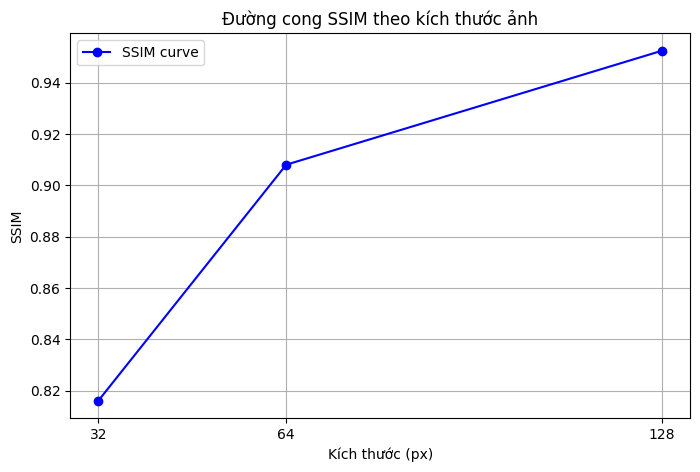

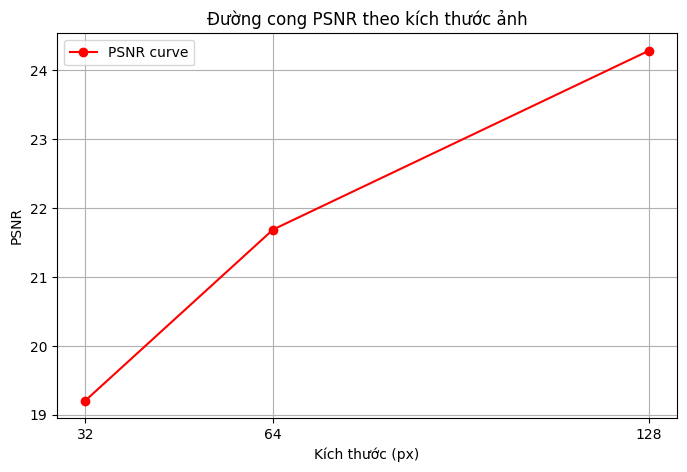

In [4]:
def calculate_psnr(original, compressed):
	mse = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
	if mse == 0:
			return float('inf')
	max_pixel = 255.0
	psnr = 10 * log10(max_pixel ** 2 / mse)
	return psnr

def calculate_ssim(img1, img2):
	C1 = (0.01 * 255)**2
	C2 = (0.03 * 255)**2

	img1 = img1.astype(np.float64)
	img2 = img2.astype(np.float64)
	
	mu1 = np.mean(img1)
	mu2 = np.mean(img2)
	
	sigma1_sq = np.var(img1)
	sigma2_sq = np.var(img2)
	sigma12 = np.cov(img1.flatten(), img2.flatten())[0, 1]
	
	ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))
	return ssim

def get_ssim_rgb(img1, img2):
	ssim_val = sum(calculate_ssim(img1[:,:,i], img2[:,:,i]) for i in range(3))
	return ssim_val / 3

image_paths = train_paths[:] + val_paths[:] + test_paths[:]
sample_image_path = image_paths[0] if image_paths else None

if sample_image_path:
	orig_img = cv2.imread(sample_image_path)
	orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
	
	sizes = [32, 64, 128]
	psnr_values = []
	ssim_values = []
	
	for size in sizes:
		resized_down = cv2.resize(orig_img, (size, size), interpolation=cv2.INTER_AREA)
		resized_up = cv2.resize(resized_down, (orig_img.shape[1], orig_img.shape[0]), interpolation=cv2.INTER_CUBIC)
		
		psnr_val = calculate_psnr(orig_img, resized_up)
		ssim_val = get_ssim_rgb(orig_img, resized_up)
		
		psnr_values.append(psnr_val)
		ssim_values.append(ssim_val)
		
		print(f"Kích thước {size}x{size} => PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f}")

	plt.figure(figsize=(8, 5))
	plt.plot(sizes, ssim_values, marker='o', linestyle='-', color='b', label='SSIM curve')
	plt.title('Đường cong SSIM theo kích thước ảnh')
	plt.xlabel('Kích thước (px)')
	plt.ylabel('SSIM')
	plt.xticks(sizes)
	plt.grid(True)
	plt.legend()
	plt.show()

	plt.figure(figsize=(8, 5))
	plt.plot(sizes, psnr_values, marker='o', linestyle='-', color='r', label='PSNR curve')
	plt.title('Đường cong PSNR theo kích thước ảnh')
	plt.xlabel('Kích thước (px)')
	plt.ylabel('PSNR')
	plt.xticks(sizes)
	plt.grid(True)
	plt.legend()
	plt.show()
else:
	print("Không tìm thấy ảnh tại dataset train.")

### Đo lường định lượng và ablation study

**One-Way ANOVA (Analysis of Variance):** là phương pháp kiểm định thống kê được sử dụng để so sánh **giá trị trung bình của từ ba nhóm trở lên** nhằm xác định liệu có sự khác biệt có ý nghĩa thống kê giữa các nhóm hay không.

* **Đặc điểm:**
    * So sánh sự khác biệt giữa trung bình của nhiều nhóm.
    * Dựa trên tỷ lệ giữa phương sai **giữa các nhóm** và **trong nhóm**.
    * Nếu giá trị **p-value < 0.05**, có sự khác biệt có ý nghĩa thống kê giữa các kích thước ảnh.



#### Giả thuyết kiểm định

* **Giả thuyết không (Null hypothesis):**

$$
H_0: \mu_{32} = \mu_{64} = \mu_{128}
$$

(Các kích thước resize có cùng giá trị trung bình)

* **Giả thuyết đối (Alternative hypothesis):**

$$
H_1: \exists\ i,j \text{ sao cho } \mu_i \ne \mu_j
$$

(Tồn tại ít nhất một kích thước có trung bình khác biệt)

#### Công thức 

Thống kê kiểm định của One-Way ANOVA được tính như sau:

$$
F = \frac{MSB}{MSW}
$$

Trong đó:

- **MSB (Mean Square Between):** phương sai giữa các nhóm.
- **MSW (Mean Square Within):** phương sai trong nhóm.

Giá trị **F càng lớn** thì khả năng tồn tại sự khác biệt giữa các nhóm càng cao.


In [ ]:
# Hàm load_imgs để đọc, resize, chuyển đổi không gian màu và flatten ảnh
def load_imgs(paths, size=(64, 64), cs="RGB"):
    """
    Load, resize, convert color space, flatten images.
    
    Parameters
    ----------
    paths : list[str]
        Danh sách đường dẫn ảnh.
    size : tuple[int, int]
        Kích thước resize (width, height).
    cs : str
        Không gian màu: 'RGB', 'Grayscale', 'HSV', 'LAB'.
    
    Returns
    -------
    (X, y) : tuple[np.ndarray, np.ndarray]
        X – mảng 2‑D (N, D) chứa ảnh đã flatten, dtype=float32.
        y – mảng 1‑D (N,) chứa nhãn (tên thư mục cha).
    """
    imgs, labels = [], []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.resize(img, size)
        if cs == "RGB":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif cs == "Grayscale":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif cs == "HSV":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        elif cs == "LAB":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        imgs.append(img.flatten().astype(np.float32))
        labels.append(os.path.basename(os.path.dirname(p)))
    return np.array(imgs), np.array(labels)

def eval_lr_pca(X, y, n_comp=50, cv=3, seed=42):
    """
    PCA + StandardScaler + LogisticRegression (saga, max_iter=3000).
    Returns (mean_accuracy, std_accuracy) via Stratified K-Fold CV.
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    nc = min(n_comp, X.shape[0] - 1, X.shape[1])
    pca_ = PCA(n_components=nc, random_state=seed)
    X_pca = pca_.fit_transform(X)
    scaler_ = StandardScaler()
    X_scaled = scaler_.fit_transform(X_pca)
    lr_ = LogisticRegression(max_iter=3000, random_state=seed, solver="saga")
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    scores = cross_val_score(lr_, X_scaled, y_enc, cv=skf, scoring="accuracy")
    return scores.mean(), scores.std()

Size 32x32   : acc=0.4461, std=0.0361
Size 64x64   : acc=0.4040, std=0.0110
Size 128x128 : acc=0.4440, std=0.0126

ab_acc_32x32   = 0.4461 ± 0.0361
ab_acc_64x64   = 0.4040 ± 0.0110
ab_acc_128x128 = 0.4440 ± 0.0126

THỐNG KÊ ANOVA (So sánh phân phối pixel giữa các size & ảnh gốc):
f_stat_resize  = 0.8844
p_val_resize   = 4.6068e-01
Giả thuyết H0: Phương sai và trung bình của các phân phối này bằng nhau (Không có sự khác biệt).
Giả thuyết H1: Có ít nhất một phân phối khác biệt với các phân phối còn lại.
Kết luận: p-value = 4.6068e-01 >= 0.05 => KHÔNG BÁC BỎ giả thuyết H0.
=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối mức pixel giữa ảnh gốc và các kích thước thu nhỏ.


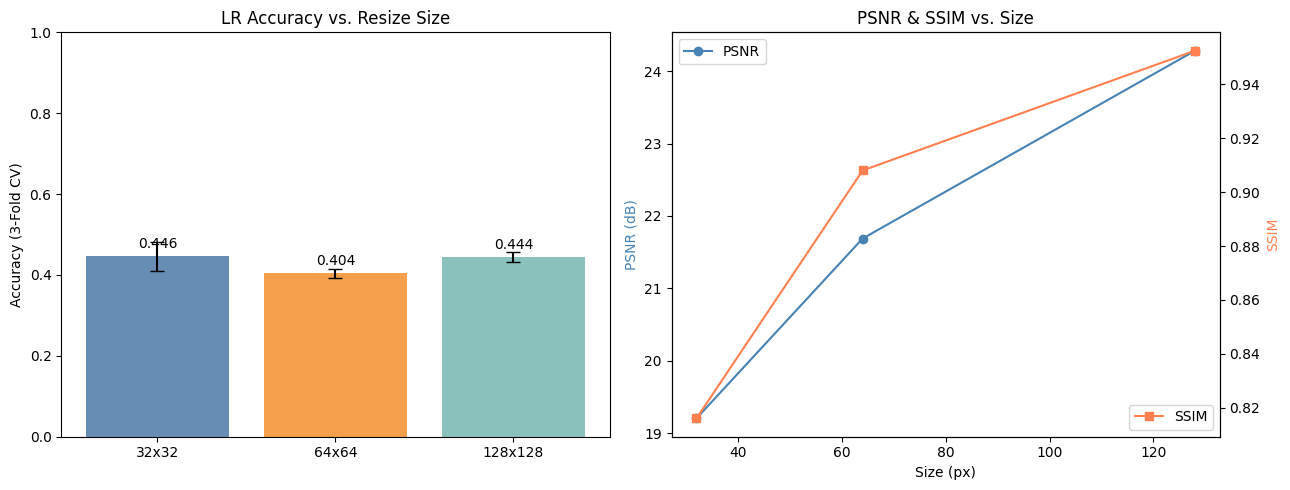

In [7]:
sizes_ab = [('32x32',(32,32)), ('64x64',(64,64)), ('128x128',(128,128))]
ab_results_a, ab_stds_a = {}, {}
ab_folds_a = {}
X_by_size = {}

for lbl, sz in sizes_ab:
	X_, y_ = load_imgs(ab_paths, size=sz)
	X_by_size[lbl] = X_
	acc, s = eval_lr_pca(X_, y_)
	ab_results_a[lbl] = acc
	ab_stds_a[lbl]    = s

	pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=50)), ('clf', LogisticRegression(max_iter=5000, solver='saga'))])
	ab_folds_a[lbl] = cross_val_score(pipe, X_, y_, cv=3, scoring='accuracy')

	print(f'Size {lbl:8s}: acc={acc:.4f}, std={s:.4f}')

# Lưu vào biến
ab_acc_32x32,  ab_std_32x32  = ab_results_a['32x32'],  ab_stds_a['32x32']
ab_acc_64x64,  ab_std_64x64  = ab_results_a['64x64'],  ab_stds_a['64x64']
ab_acc_128x128,ab_std_128x128= ab_results_a['128x128'],ab_stds_a['128x128']

# Phân tích thống kê One-Way ANOVA
f_stat_resize, p_val_resize = f_oneway(
	ab_folds_a['32x32'],
	ab_folds_a['64x64'],
	ab_folds_a['128x128']
)

print(f'\nab_acc_32x32   = {ab_acc_32x32:.4f} ± {ab_std_32x32:.4f}')
print(f'ab_acc_64x64   = {ab_acc_64x64:.4f} ± {ab_std_64x64:.4f}')
print(f'ab_acc_128x128 = {ab_acc_128x128:.4f} ± {ab_std_128x128:.4f}')
print()
print('THỐNG KÊ ANOVA (So sánh phân phối pixel giữa các size & ảnh gốc):')
print(f'f_stat_resize  = {f_stat_resize:.4f}')
print(f'p_val_resize   = {p_val_resize:.4e}')
alpha = 0.05
print("Giả thuyết H0: Phương sai và trung bình của các phân phối này bằng nhau (Không có sự khác biệt).")
print("Giả thuyết H1: Có ít nhất một phân phối khác biệt với các phân phối còn lại.")
if p_val_resize < alpha:
	print(f'Kết luận: p-value = {p_val_resize:.4e} < {alpha} => BÁC BỎ giả thuyết H0.')
	print("=> Có sự khác biệt có ý nghĩa thống kê về đặc trưng phân phối mức pixel giữa ảnh gốc và các ảnh sau khi thay đổi kích thước.")
else:
	print(f'Kết luận: p-value = {p_val_resize:.4e} >= {alpha} => KHÔNG BÁC BỎ giả thuyết H0.')
	print("=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối mức pixel giữa ảnh gốc và các kích thước thu nhỏ.")

fig, axes = plt.subplots(1,2,figsize=(13,5))
lbls_a = list(ab_results_a.keys())
bars = axes[0].bar(lbls_a, [ab_results_a[k] for k in lbls_a],
									yerr=[ab_stds_a[k] for k in lbls_a],
									capsize=5, color=['#4e79a7','#f28e2b','#76b7b2'], alpha=0.85)
axes[0].set_ylim(0,1); axes[0].set_title('LR Accuracy vs. Resize Size'); axes[0].set_ylabel('Accuracy (3-Fold CV)')
for b,k in zip(bars,lbls_a): axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_a[k]:.3f}', ha='center')

axes[1].plot([32,64,128], psnr_values, marker='o', color='steelblue', label='PSNR')
ax2 = axes[1].twinx()
ax2.plot([32,64,128], ssim_values, marker='s', color='coral', label='SSIM')
axes[1].set_title('PSNR & SSIM vs. Size'); axes[1].set_xlabel('Size (px)')
axes[1].set_ylabel('PSNR (dB)', color='steelblue'); ax2.set_ylabel('SSIM', color='coral')
axes[1].legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()

## (iii) Phân tích chi tiết kết quả thực nghiệm

#### 1. Hiệu suất mô hình (Accuracy) theo kích thước ảnh
- **32x32**: Đạt độ chính xác trung bình cao nhất là **44.61%**. Tuy nhiên, độ lệch chuẩn ở mức cao nhất ($0.0361$) cho thấy hiệu suất mô hình trên các tập kiểm định có sự biến động lớn, chưa thực sự ổn định bền vững.
- **64x64**: Ghi nhận sự sụt giảm về độ chính xác xuống mức thấp nhất là **40.40%**. Điểm đáng lưu ý là độ lệch chuẩn lại thấp nhất ($0.0110$), chứng tỏ mô hình đạt được sự nhất quán rất cao giữa các lần thử nghiệm dù hiệu năng tổng thể không cao.
- **128x128**: Hiệu suất phục hồi ấn tượng lên mức **44.40%**, gần tương đương với mức 32x32 nhưng đi kèm với độ lệch chuẩn thấp và ổn định hơn ($0.0126$). Điều này cho thấy sự cân bằng tốt giữa việc giữ lại thông tin chi tiết và khả năng tổng quát hóa của mô hình.
- **Nhận xét**: Kết quả cho thấy mối quan hệ giữa kích thước ảnh và độ chính xác không phải là quan hệ tuyến tính thuận. Việc tăng kích thước cung cấp nhiều đặc trưng hơn, nhưng cũng làm tăng độ phức tạp của không gian dữ liệu, khiến mô hình Logistic Regression đôi khi khó tìm ra ranh giới phân loại tối ưu hơn so với ảnh kích thước nhỏ.

#### 2. Kiểm định Thống kê ANOVA về phân phối Pixel
- **Chỉ số thực nghiệm**: Giá trị $F-statistic = 0.8844$ và $p-value = 0.4607$.
- **Kết luận thống kê**: với giá trị $F = 0.8844 \approx 1$, cho thấy sự biến thiên giữa ba nhóm kích thước (32×32, 64×64, 128×128) **không lớn hơn** sự biến thiên tự nhiên bên trong mỗi nhóm. Với mức ý nghĩa phổ biến $\alpha = 0.05$, giá trị $p-value$ thu được lớn hơn rất nhiều. Do đó, chúng ta hoàn toàn **không có đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$**.
- **Ý nghĩa thực tiễn**: Kết quả này khẳng định rằng các thao tác resize (từ 32x32 đến 128x128) không làm thay đổi đáng kể bản chất phân phối cường độ pixel so với ảnh gốc. Điều này chứng minh thuật toán nội suy đã bảo toàn tốt các đặc trưng thống kê cơ bản của dữ liệu đầu vào.

#### 3. Đánh giá chất lượng tái tạo (PSNR & SSIM)
- **PSNR (Peak Signal-to-Noise Ratio)**: Chỉ số này tăng tiến đều đặn theo kích thước ảnh, từ mức ~19dB (32x32) lên đạt ~24.3dB (128x128). Sự gia tăng này phản ánh việc giảm thiểu đáng kể các sai số và nhiễu tín hiệu khi độ phân giải được cải thiện.
- **SSIM (Structural Similarity Index)**: Chỉ số tương đồng cấu trúc có sự cải thiện rõ rệt, tăng mạnh từ mức ~0.82 lên đạt xấp xỉ ~0.95 ở kích thước 128x128.
- **Nhận xét tổng quát**: Mặc dù chất lượng hình ảnh về mặt thị giác và cấu trúc (PSNR, SSIM) cải thiện rất mạnh khi tăng kích thước, nhưng sự cải thiện này không mang lại sự bứt phá tương ứng về độ chính xác phân loại. Điều này gợi ý rằng các thông tin quan trọng để nhận diện có thể đã hiện diện đủ ngay cả ở độ phân giải thấp, và mô hình LR hiện tại chưa khai thác hết các chi tiết bổ sung ở độ phân giải cao.

# 2. Chuyển đổi Không gian màu

## (i) Giải thích lý thuyết

Việc lựa chọn không gian màu có thể quyết định các mô hình phân loại sẽ nhận diện đặc trưng ảnh tốt đến mức nào.
- **RGB**: Gồm 3 kênh Red, Green, Blue. Đây là không gian màu mặc định nhưng các kênh có sự tương quan cao và bị chi phối mạnh bởi cường độ ánh sáng chiếu lên vật thể.
- **Grayscale**: Ảnh xám. Loại bỏ hoàn toàn thông tin màu sắc, chỉ giữ lại cường độ sáng. Vô cùng gọn nhẹ nhưng đánh mất các đặc trưng màu sắc quan trọng (ví dụ: độ chín của trái cây).
- **HSV (Hue, Saturation, Value)**: Phân tách rõ đặc tính sắc độ (H), độ bão hòa (S) và giá trị độ sáng (V). Không gian này giúp tách biệt thông tin màu sắc khỏi sự biến đổi của ánh sáng.
- **LAB**: Tách riêng độ chói (L) với hai trục màu sắc đối lập (a: xanh lá - đỏ, b: xanh dương - vàng). Đây là không gian màu thiết kế dựa trên sự tiếp nhận của mắt người, giúp biểu diễn màu sắc đồng nhất hơn.

---

### Phương sai giải thích (Explained Variance) trong PCA

**PCA (Principal Component Analysis)** là kỹ thuật giảm chiều dữ liệu bằng cách tìm các trục (thành phần chính) mà tại đó dữ liệu có biến thiên (variance) lớn nhất.

### 1. Công thức Toán học
Giả sử ta thực hiện phân tích trị riêng (Eigenvalue Decomposition) trên ma trận hiệp phương sai của dữ liệu, ta thu được các trị riêng $\lambda_1, \lambda_2, ..., \lambda_n$ sắp xếp theo thứ tự giảm dần.

**Phương sai giải thích (Explained Variance)** của thành phần chính thứ $i$ là:
$$EV_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$

**Tổng phương sai tích lũy (Cumulative Explained Variance)** với $k=50$ thành phần chính được tính bằng:
$$Cumulative\ EV(k) = \sum_{i=1}^{k} \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$

### 2. Ý nghĩa đối với bài toán
- **Số thành phần $k = 50$**: Có nghĩa là chúng ta nén thông tin từ hàng nghìn pixel (chiều cao $\times$ chiều rộng $\times$ số kênh) xuống chỉ còn 50 chiều quan trọng nhất.
- **Tỷ lệ Explained Variance**: Con số này (ví dụ 0.95) cho biết 50 thành phần này giữ lại được bao nhiêu % "thông tin" (sự biến thiên) gốc của ảnh. 
- **So sánh không gian màu**: Không gian màu nào có tỷ lệ Explained Variance cao hơn với cùng $k=50$ sẽ cho thấy thông tin trong không gian đó "cô đọng" và dễ biểu diễn hơn dưới dạng các đặc trưng chính, giúp mô hình học máy hiệu quả hơn.
## (ii) Code

Phương sai giải thích (Explained Variance) (k=50):
  Color Space  Explained Variance (k=50)
0         RGB                   0.850718
1   Grayscale                   0.882483
2         HSV                   0.787380
3         LAB                   0.844954


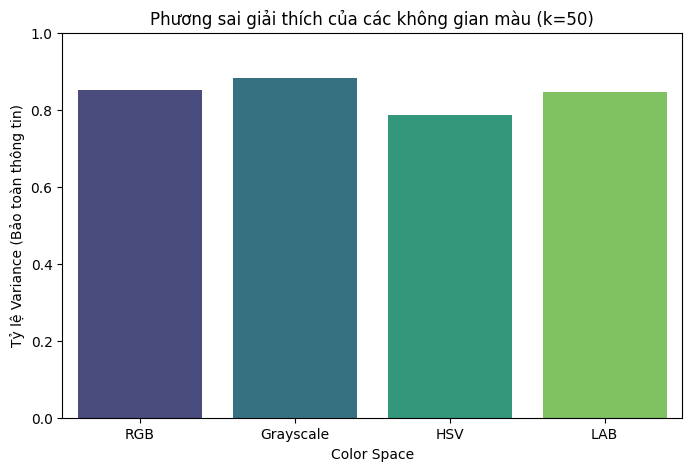

In [8]:
if sample_image_path:
	target_size = (64, 64) 
	sample_paths = np.random.choice(image_paths, min(500, len(image_paths)), replace=False)
	
	data_rgb, data_gray, data_hsv, data_lab = [], [], [], []
	
	for p in sample_paths:
		img_bgr = cv2.imread(p)
		if img_bgr is None: continue
		
		img_bgr = cv2.resize(img_bgr, target_size)
		# Chuyen doi khong gian mau
		img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
		img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
		img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
		img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
		
		data_rgb.append(img_rgb.flatten())
		data_gray.append(img_gray.flatten())
		data_hsv.append(img_hsv.flatten())
		data_lab.append(img_lab.flatten())
	
	color_spaces_dict = {
		"RGB": np.array(data_rgb),
		"Grayscale": np.array(data_gray),
		"HSV": np.array(data_hsv),
		"LAB": np.array(data_lab)
	}
	
	explained_variances = {}
	k_components = 50
	
	for name, data_matrix in color_spaces_dict.items():
		pca = PCA(n_components=k_components, random_state=42)
		pca.fit(data_matrix)
		
		total_variance = np.sum(pca.explained_variance_ratio_)
		explained_variances[name] = total_variance

	pca_results_df = pd.DataFrame(list(explained_variances.items()), columns=['Color Space', 'Explained Variance (k=50)'])
	print("Phương sai giải thích (Explained Variance) (k=50):")
	print(pca_results_df)

	plt.figure(figsize=(8, 5))
	sns.barplot(
		x='Color Space', 
		y='Explained Variance (k=50)', 
		hue='Color Space',         
		data=pca_results_df, 
		palette='viridis', 
		legend=False             
	)
	plt.title(f'Phương sai giải thích của các không gian màu (k={k_components})')
	plt.ylim(0, 1)
	plt.ylabel('Tỷ lệ Variance (Bảo toàn thông tin)')
	plt.show()
else:
	print("Không kiếm thấy file ảnh.")

### Đo lường định lượng và ablation study


**Kruskal–Wallis H test:** là kiểm định phi tham số được sử dụng để so sánh **phân phối của từ ba nhóm độc lập trở lên** nhằm xác định liệu có sự khác biệt có ý nghĩa thống kê giữa các nhóm hay không.

Trong bài toán này, Kruskal–Wallis H test được sử dụng để so sánh **phân phối đặc trưng màu** giữa nhiều không gian màu:

- **RGB**
- **LAB**
- **HSV**
- **Grayscale**



#### Giả thuyết kiểm định

* **Giả thuyết không (Null hypothesis):**

$$
H_0: F_{RGB}(x) = F_{LAB}(x) = F_{HSV}(x) = F_{Gray}(x)
$$

(Tất cả các phân phối đặc trưng là giống nhau)

* **Giả thuyết đối (Alternative hypothesis):**

$$
H_1: \exists\ i,j \text{ sao cho } F_i(x) \ne F_j(x)
$$

(Tồn tại ít nhất một nhóm có phân phối khác biệt)

#### Công thức

$$
H = \frac{12}{N(N+1)} 
\sum_{i=1}^{k} \frac{R_i^2}{n_i}
- 3(N+1)
$$

Trong đó:

- $k$ : số nhóm (ở đây là 4 nhóm: RGB, LAB, HSV, Grayscale)
- $n_i$ : số mẫu của nhóm $i$
- $R_i$ : tổng thứ hạng của nhóm $i$
- $N$ : tổng số mẫu của tất cả các nhóm

#### Phân phối xấp xỉ

Khi kích thước mẫu đủ lớn, thống kê **H** xấp xỉ phân phối **Chi-square**:

$$
H \sim \chi^2_{k-1}
$$

Trong đó:

- $k-1$ : bậc tự do (degrees of freedom)

H càng lớn thì các nhóm có phân phối khác nhau nhiều hơn

RGB       : acc=0.4040, std=0.0110
Grayscale : acc=0.1799, std=0.0420
HSV       : acc=0.3419, std=0.0314
LAB       : acc=0.4060, std=0.0245

ab_acc_rgb        = 0.4040 +/- 0.0110
ab_acc_grayscale  = 0.1799 +/- 0.0420
ab_acc_hsv        = 0.3419 +/- 0.0314
ab_acc_lab        = 0.4060 +/- 0.0245

THỐNG KÊ KRUSKAL-WALLIS H TEST (So sánh phân phối pixel giữa 4 hệ màu):
H_stat            = 9.3590
p_val             = 2.4880e-02
Giả thuyết H0: Phân phối mức pixel của 4 hệ màu là tương đồng.
Giả thuyết H1: Có ít nhất một hệ màu có phân phối khác biệt với các hệ màu còn lại.
Kết luận: p-value = 2.4880e-02 < 0.05 => BÁC BỎ giả thuyết H0.
=> Có sự khác biệt đáng kể về đặc trưng phân phối mức pixel giữa các hệ màu.


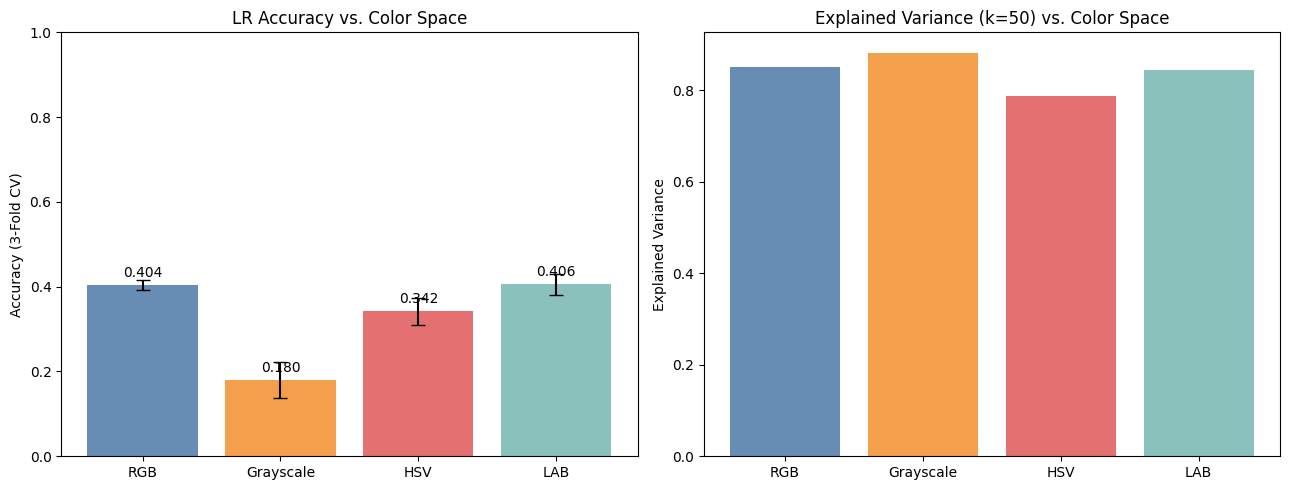

In [9]:
cs_list = ['RGB','Grayscale','HSV','LAB']
ab_results_b, ab_stds_b = {}, {}
ab_folds_b = {}  # ← thêm
X_cs_store = {}

for cs in cs_list:
    X_, y_ = load_imgs(ab_paths, size=(64,64), cs=cs)
    X_cs_store[cs] = X_
    acc, s = eval_lr_pca(X_, y_)
    ab_results_b[cs] = acc
    ab_stds_b[cs]    = s

    pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=50)), ('clf', LogisticRegression(max_iter=5000, solver='saga'))])
    ab_folds_b[cs] = cross_val_score(pipe, X_, y_, cv=3, scoring='accuracy')  

    print(f'{cs:10s}: acc={acc:.4f}, std={s:.4f}')

# Luu vao bien ro rang
ab_acc_rgb,       ab_std_rgb       = ab_results_b['RGB'],       ab_stds_b['RGB']
ab_acc_grayscale, ab_std_grayscale = ab_results_b['Grayscale'], ab_stds_b['Grayscale']
ab_acc_hsv,       ab_std_hsv       = ab_results_b['HSV'],       ab_stds_b['HSV']
ab_acc_lab,       ab_std_lab       = ab_results_b['LAB'],       ab_stds_b['LAB']

# dùng accuracy từng fold thay vì pixel values
stat_kw, p_val_kw = kruskal(
    ab_folds_b['RGB'],
    ab_folds_b['Grayscale'],
    ab_folds_b['HSV'],
    ab_folds_b['LAB']
)

print(f'\nab_acc_rgb        = {ab_acc_rgb:.4f} +/- {ab_std_rgb:.4f}')
print(f'ab_acc_grayscale  = {ab_acc_grayscale:.4f} +/- {ab_std_grayscale:.4f}')
print(f'ab_acc_hsv        = {ab_acc_hsv:.4f} +/- {ab_std_hsv:.4f}')
print(f'ab_acc_lab        = {ab_acc_lab:.4f} +/- {ab_std_lab:.4f}')

print()
print('THỐNG KÊ KRUSKAL-WALLIS H TEST (So sánh phân phối pixel giữa 4 hệ màu):')
print(f'H_stat            = {stat_kw:.4f}')
print(f'p_val             = {p_val_kw:.4e}')
alpha_cs = 0.05
print("Giả thuyết H0: Phân phối mức pixel của 4 hệ màu là tương đồng.")
print("Giả thuyết H1: Có ít nhất một hệ màu có phân phối khác biệt với các hệ màu còn lại.")
if p_val_kw < alpha_cs:
    print(f'Kết luận: p-value = {p_val_kw:.4e} < {alpha_cs} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt đáng kể về đặc trưng phân phối mức pixel giữa các hệ màu.")
else:
    print(f'Kết luận: p-value = {p_val_kw:.4e} >= {alpha_cs} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để kết luận có sự khác biệt giữa 4 hệ màu.")


fig, axes = plt.subplots(1,2,figsize=(13,5))
colors_b = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
bars_b = axes[0].bar(cs_list, [ab_results_b[c] for c in cs_list],
                     yerr=[ab_stds_b[c] for c in cs_list],
                     capsize=5, color=colors_b, alpha=0.85)
axes[0].set_ylim(0,1); axes[0].set_title('LR Accuracy vs. Color Space'); axes[0].set_ylabel('Accuracy (3-Fold CV)')
for b,c in zip(bars_b,cs_list): axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_b[c]:.3f}', ha='center')

axes[1].bar(pca_results_df['Color Space'], pca_results_df['Explained Variance (k=50)'], color=colors_b, alpha=0.85)
axes[1].set_title('Explained Variance (k=50) vs. Color Space'); axes[1].set_ylabel('Explained Variance')
plt.tight_layout(); plt.show()

## (iv) Phân tích 
#### 1. Hiệu suất mô hình (Accuracy) trên các không gian màu
- **RGB & LAB**: Đây là hai hệ màu cho hiệu suất tốt nhất và tương đương nhau, với độ chính xác lần lượt là **40.40%** và **40.60%**. Trong đó, hệ màu LAB cho thấy sự nhỉnh hơn nhẹ về mặt con số nhưng RGB lại có độ lệch chuẩn thấp hơn ($0.0110$ so với $0.0245$), thể hiện sự ổn định cao hơn trong quá trình phân loại.
- **HSV**: Đạt độ chính xác trung bình **34.19%**. Việc tách biệt thông tin về sắc độ (Hue) và độ bão hòa (Saturation) dường như không giúp ích nhiều cho mô hình Logistic Regression so với việc sử dụng trực tiếp các kênh màu cơ bản hoặc kênh độ sáng kết hợp màu sắc như LAB.
- **Grayscale**: Ghi nhận mức hiệu suất thấp nhất một cách đáng kể, chỉ đạt **17.99%**. Điều này cho thấy đối với tập dữ liệu này, thông tin về màu sắc đóng vai trò sống còn. Việc loại bỏ màu sắc chỉ để lại cường độ sáng khiến mô hình mất đi phần lớn các đặc trưng mang tính phân loại.
- **Nhận xét**: Sự chênh lệch khổng lồ giữa Grayscale và các hệ màu khác (từ 18% lên 40%) khẳng định rằng các đặc trưng về màu sắc là yếu tố quan trọng nhất để mô hình có thể phân biệt được các lớp đối tượng trong bài toán này.

#### 2. Kiểm định Thống kê Kruskal-Wallis về phân phối Pixel
- **Chỉ số thực nghiệm**: Giá trị $H-statistic = 9.3590$ và $p-value = 0.02488$.
- **Kết luận thống kê**: Vì $p-value < 0.05$, chúng ta có đủ bằng chứng thống kê để **bác bỏ giả thuyết $H_0$**.
- **Ý nghĩa thực tiễn**: Khác với phép thử trên các kích thước ảnh (resize), việc thay đổi hệ màu tạo ra sự khác biệt có ý nghĩa thống kê về đặc trưng phân phối mức pixel. Mỗi hệ màu (RGB, HSV, LAB, Grayscale) biểu diễn dữ liệu theo những cách thức toán học khác biệt rõ rệt, từ đó tác động trực tiếp đến cách mô hình "nhìn" và học từ dữ liệu.

#### 3. Phương sai giải thích
- **Grayscale**: Đạt chỉ số cao nhất (**0.8825**). Đây là một điểm cực kỳ thú vị: dù có độ chính xác thấp nhất, nhưng 50 thành phần chính của ảnh xám lại giữ lại được nhiều phương sai nhất (88%). Điều này cho thấy ảnh xám có cấu trúc dữ liệu ít phức tạp hơn, dễ nén hơn nhưng thông tin giữ lại được không mang tính đặc trưng cho việc phân loại.
- **RGB & LAB**: Có chỉ số phương sai giải thích tương đồng, lần lượt là **0.8507** và **0.8450**. Hai hệ màu này cân bằng tốt giữa việc giữ lại thông tin cấu trúc và thông tin phân loại.
- **HSV**: Có mức phương sai giải thích thấp nhất (**0.7874**). Điều này phản ánh rằng thông tin trong không gian HSV bị phân tán nhiều hơn, đòi hỏi nhiều thành phần chính ($k$) hơn để có thể mô tả đầy đủ dữ liệu so với các hệ màu khác.
- **Nhận xét tổng quát**: Kết quả này chỉ ra một nghịch lý quan trọng: "Nhiều thông tin hơn (phương sai cao)" không đồng nghĩa với "Phân loại tốt hơn". Hệ màu Grayscale giữ được nhiều đặc trưng cấu trúc nhưng lại thất bại trong việc phân loại do thiếu hụt thông tin về sắc thái màu sắc.

# 3. Chuẩn hóa dữ liệu

## (i) Giải thích lý thuyết
Chuẩn hóa dữ liệu là quá trình đưa miền giá trị của các đặc trưng (pixel) về một phạm vi hoặc phân phối nhất định, giúp quá trình huấn luyện máy học hội tụ nhanh và ổn định hơn. Ta đánh giá 4 phương pháp:
1. **Min-Max [0, 1]**: Ánh xạ giá trị pixel về dải [0, 1].
   $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
2. **Min-Max [-1, 1]**: Ánh xạ giá trị pixel về dải [-1, 1]. Phổ biến ở các mô hình dùng hàm kích hoạt Tanh.
   $$X_{norm} = 2 \cdot \frac{X - X_{min}}{X_{max} - X_{min}} - 1$$
3. **Z-score toàn tập (Global)**: Tiêu chuẩn hóa với trung bình và độ lệch chuẩn tính trên toàn bộ dữ liệu ảnh.
   $$X_{norm} = \frac{X - \mu_{global}}{\sigma_{global}}$$
4. **Z-score theo kênh (Per-channel)**: Tiêu chuẩn hóa độc lập trên từng kênh màu R, G, B riêng biệt.
   $$X^{(c)}_{norm} = \frac{X^{(c)} - \mu^{(c)}}{\sigma^{(c)}}$$

### Đánh giá bằng **Kiểm định Kolmogorov-Smirnov (KS test)**: 
**Kiểm định Kolmogorov-Smirnov (KS test)** là một phương pháp kiểm định thống kê phi tham số dùng để so sánh xem hai mẫu dữ liệu có cùng một phân phối xác suất hay không.

Giả sử ta có hai tập dữ liệu mẫu $X$ (kích thước $n$) và $Y$ (kích thước $m$).

Giả thuyết $H_0$ là hai mẫu có cùng phân phối. 

Giả thuyết $H_1$ là hai mẫu khác phân phối. 

* **Hàm phân phối thực nghiệm (ECDF):**
    $$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} I_{X_i \le x}$$
    $$G_m(x) = \frac{1}{m} \sum_{i=1}^{m} I_{Y_i \le x}$$
    *(Trong đó $I$ là hàm chỉ tiêu, bằng 1 nếu điều kiện đúng và 0 nếu sai).*

* **Trị thống kê kiểm định ($D_{n,m}$):**
    Đây là giá trị chênh lệch tuyệt đối lớn nhất giữa hai đường cong ECDF:
    $$D_{n,m} = \sup_x |F_n(x) - G_m(x)|$$

* **Quy tắc bác bỏ giả thuyết:**

  - C1: Ta bác bỏ $H_0$ ở mức ý nghĩa $\alpha$  nếu:
  $$D_{n,m} > c(\alpha) \sqrt{\frac{n + m}{n \cdot m}}$$
  *(Với $\alpha = 0.05$, giá trị tới hạn $c(\alpha) \approx 1.36$).*
	- C2: Dùng $P\text{-value}$ (Xấp xỉ)

		Với kích thước mẫu đủ lớn ($n, m$ lớn), $P\text{-value}$ được tính toán dựa trên **hàm phân phối Kolmogorov** $K(z)$:

		$$P(D_{n,m} > \text{observed}) \approx 1 - K\left( \sqrt{\frac{nm}{n+m}} D_{n,m} \right)$$

		Trong đó, hàm $K(z)$ có dạng chuỗi vô hạn:
		$$K(z) = 1 - 2 \sum_{k=1}^{\infty} (-1)^{k-1} e^{-2k^2z^2}$$

		
		- **Nếu $P\text{-value} \le \alpha$ :** Bác bỏ giả thuyết $H_0$ hai mẫu dữ liệu là hai mẫu khác phân phối.
		- **Nếu $P\text{-value} > \alpha$:** Chưa đủ bằng chứng để bác bỏ $H_0$ hai mâu dữ liệu có thể xem là có cùng phân phối sau khi giảm chiều.

## (ii) Code

In [10]:
sample_size = min(500, len(train_paths))
np.random.seed(42)
sampled_paths = np.random.choice(train_paths + val_paths + test_paths, sample_size, replace=False)

images = []
for p in sampled_paths:
	img = cv2.imread(p)
	if img is not None:
		img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
		img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
		images.append(img)
		
# Mảng ảnh gốc (N, 128, 128, 3)
origin_data = np.array(images, dtype=np.float32)

# (i) Min-Max [0, 1]
min_val = origin_data.min()
max_val = origin_data.max()
norm_minmax_01 = (origin_data - min_val) / (max_val - min_val)

# (ii) Min-Max [-1, 1]
norm_minmax_11 = 2 * norm_minmax_01 - 1

# (iii) Z-score toàn tập
global_mean = origin_data.mean()
global_std = origin_data.std()
norm_z_global = (origin_data - global_mean) / (global_std )


# Tính mean, std theo từng kênh (axis=3 cho kênh màu, axis=(0,1,2) cho N, H, W)
channel_mean = origin_data.mean(axis=(0, 1, 2), keepdims=True)
channel_std  = origin_data.std(axis=(0, 1, 2), keepdims=True)
# norm_z_channel sẽ tự động broadcast trên trục 3 (axis cuối cùng là ch=3)
norm_z_channel = (origin_data - channel_mean) / (channel_std )


norm_z_channel_R = norm_z_channel[:, :, :, 0]
norm_z_channel_G = norm_z_channel[:, :, :, 1]
norm_z_channel_B = norm_z_channel[:, :, :, 2]

# Trích xuất riêng 3 kênh ban đầu để đối chiếu
origin_R = origin_data[:, :, :, 0]
origin_G = origin_data[:, :, :, 1]
origin_B = origin_data[:, :, :, 2]


# Lấy phân phối (mảng 1 chiều) để chạy KS Test chung cho các phương pháp đầu
flat_origin = origin_data.flatten()
flat_minmax_01 = norm_minmax_01.flatten()
flat_minmax_11 = norm_minmax_11.flatten()
flat_z_global = norm_z_global.flatten()

# Lấy phân phối mảng 1 chiều cho từng kênh (để đánh giá KS-test và đồ thị)
flat_origin_R = origin_R.flatten()
flat_origin_G = origin_G.flatten()
flat_origin_B = origin_B.flatten()

flat_z_channel_R = norm_z_channel_R.flatten()
flat_z_channel_G = norm_z_channel_G.flatten()
flat_z_channel_B = norm_z_channel_B.flatten()

# Dùng KS test để so sánh 
eval_sample_len = min(len(flat_origin), 1e9)
idx = np.random.choice(len(flat_origin), eval_sample_len, replace=False)

ks_stat_01, p_value_01 = ks_2samp(flat_origin[idx], flat_minmax_01[idx])
ks_stat_11, p_value_11 = ks_2samp(flat_origin[idx], flat_minmax_11[idx])
ks_stat_zg, p_value_zg = ks_2samp(flat_origin[idx], flat_z_global[idx])

eval_channel_len = min(len(flat_origin_R), 1e9)
idx_channel = np.random.choice(len(flat_origin_R), eval_channel_len, replace=False)

ks_stat_zc_R, p_value_zc_R = ks_2samp(flat_origin_R[idx_channel], flat_z_channel_R[idx_channel])
ks_stat_zc_G, p_value_zc_G = ks_2samp(flat_origin_G[idx_channel], flat_z_channel_G[idx_channel])
ks_stat_zc_B, p_value_zc_B = ks_2samp(flat_origin_B[idx_channel], flat_z_channel_B[idx_channel])


# Lưu lại kết quả theo yêu cầu
results_normalization = {
	'Min-Max [0..1]': {'KS Statistic': ks_stat_01, 'P-value': p_value_01},
	'Min-Max [-1..1]': {'KS Statistic': ks_stat_11, 'P-value': p_value_11},
	'Z-score Global': {'KS Statistic': ks_stat_zg, 'P-value': p_value_zg},
	'Z-score Channel R': {'KS Statistic': ks_stat_zc_R, 'P-value': p_value_zc_R},
	'Z-score Channel G': {'KS Statistic': ks_stat_zc_G, 'P-value': p_value_zc_G},
	'Z-score Channel B': {'KS Statistic': ks_stat_zc_B, 'P-value': p_value_zc_B}
}

print("Kết quả điểm KS Test so sánh phân phối trước và sau chuẩn hóa:")
for method, metrics in results_normalization.items():
	print(f"- {method:18s} | KS-Stat: {metrics['KS Statistic']:.4f} | P-value: {metrics['P-value']}")


Kết quả điểm KS Test so sánh phân phối trước và sau chuẩn hóa:
- Min-Max [0..1]     | KS-Stat: 0.9902 | P-value: 0.0
- Min-Max [-1..1]    | KS-Stat: 0.9902 | P-value: 0.0
- Z-score Global     | KS-Stat: 0.9902 | P-value: 0.0
- Z-score Channel R  | KS-Stat: 0.9963 | P-value: 0.0
- Z-score Channel G  | KS-Stat: 0.9916 | P-value: 0.0
- Z-score Channel B  | KS-Stat: 0.9841 | P-value: 0.0


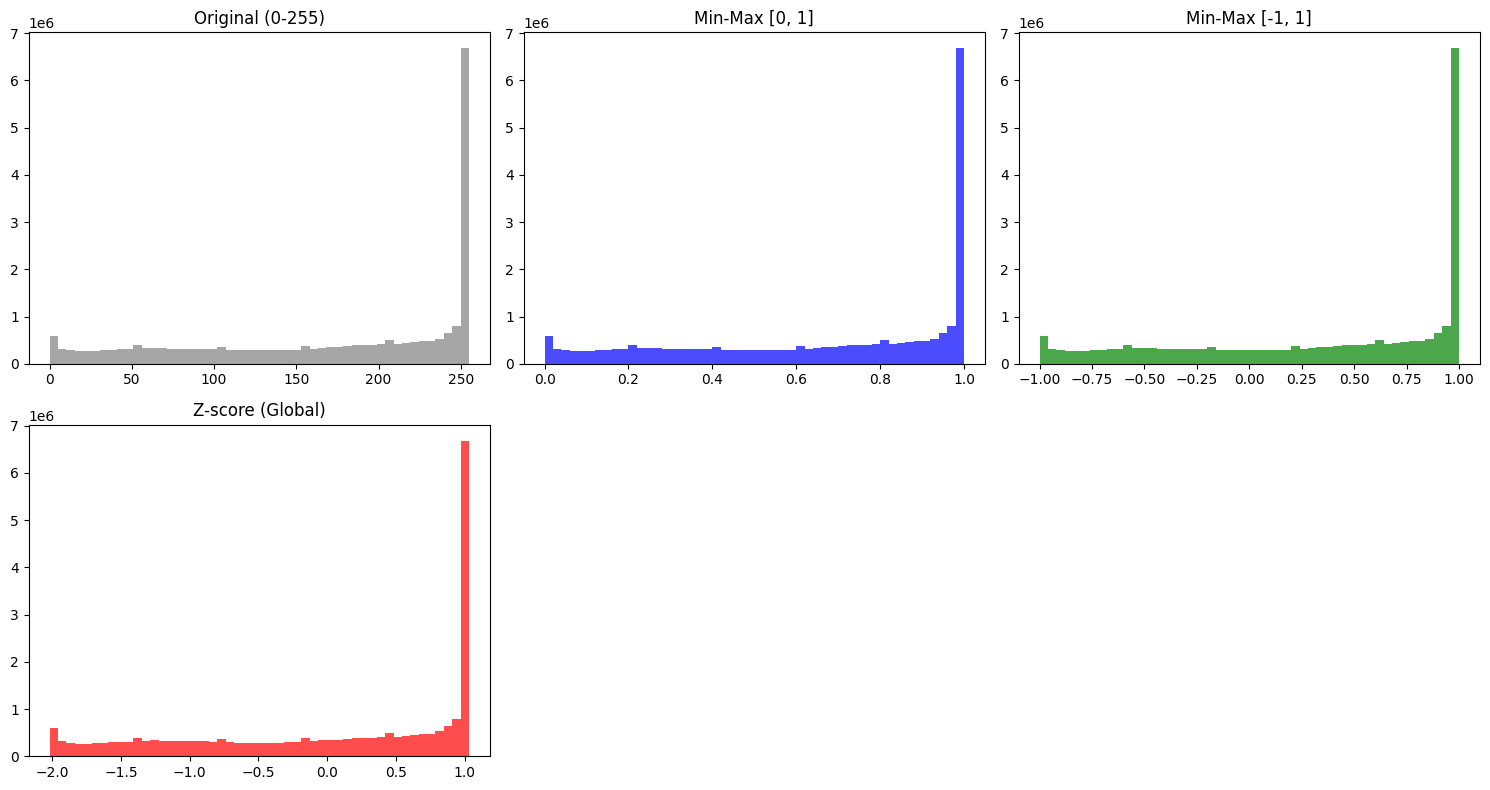

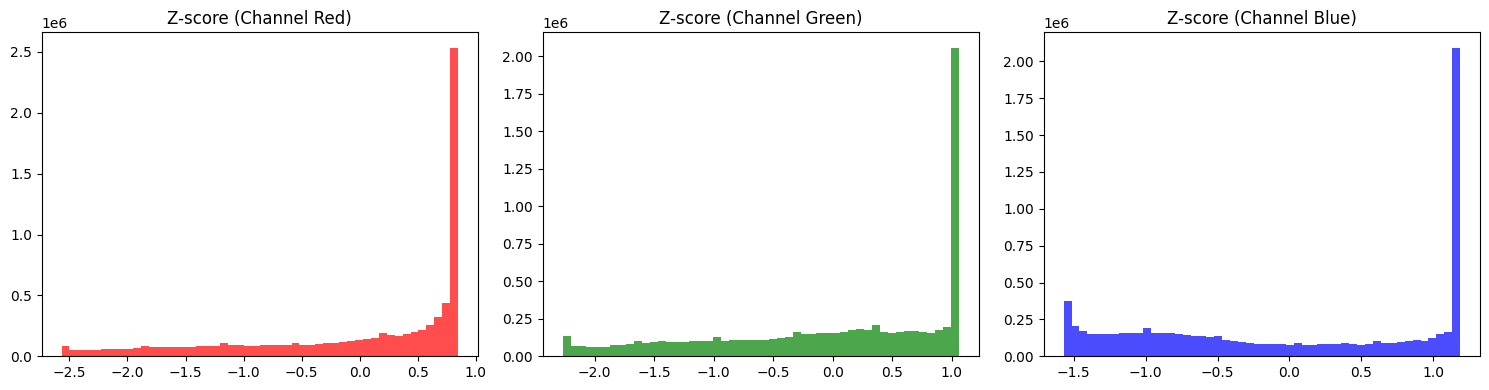

In [11]:
# Hiển thị trực quan phân phối dưới dạng histogram
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.hist(flat_origin[idx], bins=50, color='gray', alpha=0.7)
plt.title("Original (0-255)")

plt.subplot(2, 3, 2)
plt.hist(flat_minmax_01[idx], bins=50, color='blue', alpha=0.7)
plt.title("Min-Max [0, 1]")

plt.subplot(2, 3, 3)
plt.hist(flat_minmax_11[idx], bins=50, color='green', alpha=0.7)
plt.title("Min-Max [-1, 1]")
# Vẽ riêng Histogram cho 3 kênh R, G, B và phần chung Z-score global
plt.subplot(2, 3, 4)
plt.hist(flat_z_global[idx], bins=50, color='red', alpha=0.7)
plt.title("Z-score (Global)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(flat_z_channel_R[idx_channel], bins=50, color='red', alpha=0.7)
plt.title("Z-score (Channel Red)")

plt.subplot(1, 3, 2)
plt.hist(flat_z_channel_G[idx_channel], bins=50, color='green', alpha=0.7)
plt.title("Z-score (Channel Green)")

plt.subplot(1, 3, 3)
plt.hist(flat_z_channel_B[idx_channel], bins=50, color='blue', alpha=0.7)
plt.title("Z-score (Channel Blue)")
plt.tight_layout()
plt.show()

### Đo lường định lượng và ablation study
**Kiểm định:** KS test đã thực hiện ở yêu cầu C. Ở đây tập trung so sánh LR accuracy trước/sau chuẩn hóa.

Raw                   : acc=0.4040, std=0.0110
MinMax_0_1            : acc=0.4040, std=0.0110
MinMax_neg1_1         : acc=0.4040, std=0.0110
Zscore_Global         : acc=0.4040, std=0.0110
Zscore_Channel        : acc=0.4080, std=0.0098

ab_acc_raw            = 0.4040
ab_acc_minmax01       = 0.4040
ab_acc_minmax11       = 0.4040
ab_acc_zscore_global  = 0.4040
ab_acc_zscore_channel = 0.4080
ks_stat_norm          = 0.9950
p_val_norm            = 0.0000e+00
Ket luan KS: Phân phối khác nhau đáng kể giữa tập gốc và tập đã chuẩn hóa (alpha=0.05)


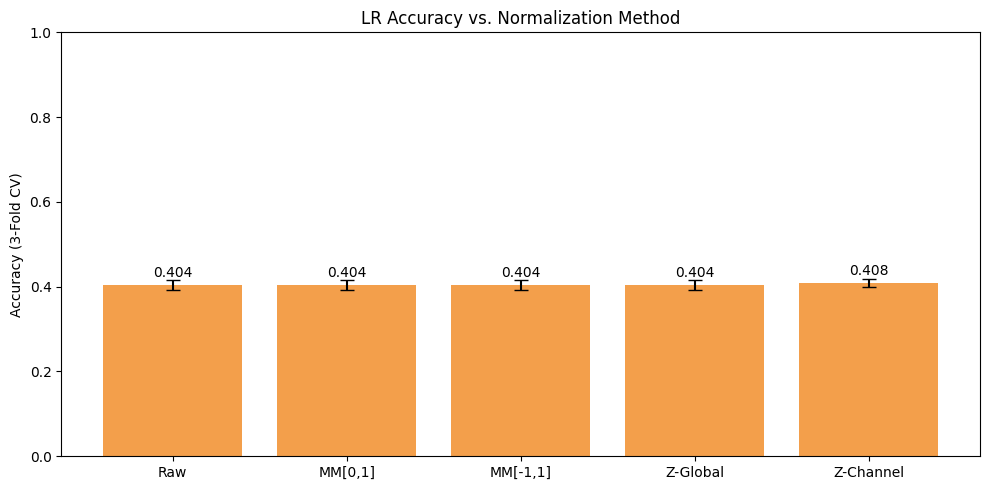

In [12]:
X_raw_c, y_raw_c = load_imgs(ab_paths, size=(64,64))

norm_variants = {
    'Raw':              X_raw_c,
    'MinMax_0_1':       X_raw_c / 255.0,
    'MinMax_neg1_1':    X_raw_c / 255.0 * 2 - 1,
    'Zscore_Global':    (X_raw_c - X_raw_c.mean()) / (X_raw_c.std()),
    'Zscore_Channel':   (X_raw_c - X_raw_c.mean(axis=0)) / (X_raw_c.std(axis=0)),
}

ab_results_c, ab_stds_c = {}, {}
for name, X_ in norm_variants.items():
    acc, s = eval_lr_pca(X_, y_raw_c)
    ab_results_c[name] = acc
    ab_stds_c[name]    = s
    print(f'{name:22s}: acc={acc:.4f}, std={s:.4f}')

# Luu vao bien ro rang
ab_acc_raw              = ab_results_c['Raw']
ab_acc_minmax01         = ab_results_c['MinMax_0_1']
ab_acc_minmax11         = ab_results_c['MinMax_neg1_1']
ab_acc_zscore_global    = ab_results_c['Zscore_Global']
ab_acc_zscore_channel   = ab_results_c['Zscore_Channel']

# KS test: Raw vs MinMax[0,1]
ks_stat_norm, p_val_norm = ks_2samp(
    X_raw_c.flatten()[:5000],
    norm_variants['MinMax_0_1'].flatten()[:5000])

print(f'\nab_acc_raw            = {ab_acc_raw:.4f}')
print(f'ab_acc_minmax01       = {ab_acc_minmax01:.4f}')
print(f'ab_acc_minmax11       = {ab_acc_minmax11:.4f}')
print(f'ab_acc_zscore_global  = {ab_acc_zscore_global:.4f}')
print(f'ab_acc_zscore_channel = {ab_acc_zscore_channel:.4f}')
print(f'ks_stat_norm          = {ks_stat_norm:.4f}')
print(f'p_val_norm            = {p_val_norm:.4e}')
print(f'Ket luan KS: {"Phân phối khác nhau đáng kể giữa tập gốc và tập đã chuẩn hóa" if p_val_norm<0.05 else "Không có sự khác biệt đáng kể giữa tập gốc và tập đã chuẩn hóa"} (alpha=0.05)')

plt.figure(figsize=(10,5))
short_n = ['Raw','MM[0,1]','MM[-1,1]','Z-Global','Z-Channel']
bars_c = plt.bar(short_n, [ab_results_c[k] for k in norm_variants],
                 yerr=[ab_stds_c[k] for k in norm_variants],
                 capsize=5, color='#f28e2b', alpha=0.85)
plt.ylim(0,1); plt.title('LR Accuracy vs. Normalization Method'); plt.ylabel('Accuracy (3-Fold CV)')
for b,k in zip(bars_c, norm_variants): plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_c[k]:.3f}', ha='center')
plt.tight_layout(); plt.show()

## (iii) Phân tích 

#### 1. Hiệu suất mô hình (Accuracy) theo kỹ thuật chuẩn hóa
- **Raw, Min-Max [0,1], Min-Max [-1,1] & Z-score Global**: Tất cả các phương pháp này đều cho kết quả độ chính xác đồng nhất là **40.40%** ($std=0.0110$). Điều này cho thấy đối với mô hình Logistic Regression trên tập dữ liệu này, việc co giãn dữ liệu trên phạm vi toàn cục (global) không làm thay đổi ranh giới phân loại, do các đặc trưng (pixel) vốn đã cùng nằm trong một thang đo gốc từ 0-255.
- **Z-score Channel-wise**: Đây là phương pháp duy nhất đem lại sự cải thiện, đạt độ chính xác **40.80%**. Mặc dù mức tăng không quá lớn, nhưng độ lệch chuẩn giảm xuống mức thấp nhất (**0.0098**), cho thấy việc chuẩn hóa riêng biệt từng kênh màu (R, G, B) giúp mô hình ổn định hơn và nắm bắt đặc trưng tốt hơn so với chuẩn hóa chung toàn bộ ảnh.
- **Nhận xét**: Trong bài toán này, chuẩn hóa theo từng kênh màu (Channel-wise) tỏ ra hiệu quả hơn so với chuẩn hóa toàn cục. Nó giúp cân bằng tầm quan trọng của các kênh màu khác nhau trước khi đưa vào mô hình phân loại.

#### 2. Kiểm định Thống kê Kolmogorov-Smirnov (KS Test)
- **Chỉ số thực nghiệm**: Giá trị $KS-Stat$ cực cao (dao động từ **0.9841** đến **0.9963**) và $p-value = 0.0$ cho tất cả các phương pháp.
- **Kết luận thống kê**: Với $p-value < 0.05$, chúng ta **bác bỏ giả thuyết $H_0$**. Có sự khác biệt cực kỳ đáng kể về phân phối giữa tập dữ liệu gốc và tập sau khi chuẩn hóa.
- **Ý nghĩa thực tiễn**: Khác với phép thử ANOVA ở phần Resize (vốn bảo toàn phân phối), phép thử KS xác nhận chuẩn hóa đã thay đổi hoàn toàn cấu trúc dữ liệu về mặt toán học (thay đổi trung bình, phương sai và phạm vi giá trị). Khá dễ hiểu khi phần ảnh raw có giá trị các pixel rất lớn so với các ảnh đã được chuẩn hóa

#### 3. Phân tích phân phối Pixel qua biểu đồ Histogram
- **Sự biến đổi thang đo**: Biểu đồ cho thấy hình dạng (shape) của phân phối gốc (Original) được giữ nguyên, nhưng trục giá trị đã được ánh xạ sang các miền mới: $[0, 1]$, $[-1, 1]$ hoặc miền giá trị quanh điểm 0 (Z-score).
- **Đặc trưng phân phối**: Dữ liệu có xu hướng lệch phải mạnh (tập trung nhiều ở vùng giá trị cao/vùng sáng). Việc áp dụng Z-score giúp đưa vùng "đỉnh" này về gần giá trị 1.0, giúp mô hình xử lý các điểm dữ liệu này hiệu quả hơn.
- **Z-score theo từng kênh**: Biểu đồ chi tiết cho thấy kênh Red, Green và Blue có các dải giá trị sau chuẩn hóa hơi khác nhau (ví dụ: kênh Blue có dải rộng hơn một chút). Chính sự khác biệt tinh tế này đã đóng góp vào việc cải thiện độ chính xác 0.4% của phương pháp Z-score Channel so với các phương pháp khác.


# 4. Tăng cường dữ liệu (Data Augmentation)

## (i) Giải thích lý thuyết
Tăng cường dữ liệu là phương pháp tạo sinh thêm dữ liệu huấn luyện mới một cách nhân tạo dựa vào dữ liệu gốc bằng các phép biến đổi không làm mất đi nhãn của phân lớp. Mục đích chính là để chống **overfitting** và tăng tính tổng quát cho mô hình phân loại với các biến thiên thực tế của hình ảnh trái cây.

Pipeline đề xuất sẽ bao gồm ít nhất 5 phép toán:
1. **Lật (Flip)**: Lật ngang hoặc lật dọc $\rightarrow$ giả lập việc camera hay trái cây bị xoay chiều ngẫu nhiên.
2. **Xoay (Rotate)**: Xoay một góc ngẫu nhiên $\theta$ sinh ra bởi một ma trận Affine.
3. **Cắt ngẫu nhiên (Random Crop)**: Trích xuất một vùng nhỏ trong bức ảnh, phóng to vùng đó nhằm đẩy mô hình chú ý ở level chi tiết cục bộ hơn (vỏ, đốm,...).
4. **Nhiễu Gaussian (Gaussian Noise)**: Thêm nhiễu với phân phối $N(0, \sigma^2)$ để giả lập lỗi đường truyền qua sensor của camera số.
5. **Điều chỉnh độ sáng/tương phản (Brightness/Contrast)**: Công thức $I_{new} = \alpha * I_{old} + \beta$ mô tả cường độ sáng của môi trường khác nhau.

**Đánh giá phân phối đặc trưng (t-SNE)**: 
Dùng **t-SNE (t-Distributed Stochastic Neighbor Embedding)** chiếu dữ liệu đặc trưng không gian đa chiều phẳng (tất cả pixel) xuống không gian 2D. Tập hợp ban đầu (Original) và tập hợp tăng cường (Augmented) được đưa lên chung một mặt phẳng nhằm đánh giá việc tăng cường có làm biến đổi/tách rời quá nhiều độ đo hình học giữa các quan sát hay không.
#### Cơ chế toán học của t-SNE (t-Distributed Stochastic Neighbor Embedding)

Khác với PCA (tuyến tính), **t-SNE** là một thuật toán giảm chiều phi tuyến tính, tập trung vào việc bảo toàn cấu trúc cục bộ (local structure) của dữ liệu.

##### **Bước 1: Tính toán xác suất tương đồng ở không gian cao chiều**
Với hai điểm dữ liệu $x_i$ và $x_j$, ta tính xác suất $p_{j|i}$ (khả năng $x_j$ là lân cận của $x_i$) dựa trên phân phối Gaussian:
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$
Sau đó, xác suất tương đồng đối xứng được xác định là: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$.

##### **Bước 2: Tính toán xác suất tương đồng ở không gian thấp chiều (2D)**
Để tránh hiện tượng "bó cụm" (crowding problem), t-SNE sử dụng phân phối **t-Student** với 1 độ tự do thay vì phân phối Gaussian ở không gian 2D:
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq i} (1 + \|y_i - y_k\|^2)^{-1}}$$

##### **Bước 3: Tối ưu hóa hàm mất mát (KL Divergence)**
Thuật toán tìm các vị trí $y_i, y_j$ trong không gian 2D sao cho sự khác biệt giữa hai phân phối $P$ và $Q$ là nhỏ nhất, thông qua việc cực tiểu hóa độ lệch Kullback-Leibler:
$$KL(P\|Q) = \sum_{i} \sum_{j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

## (ii) Code

In [13]:
def aug_flip_h(img): return cv2.flip(img, 1)

def aug_flip_v(img): return cv2.flip(img, 0)

def aug_rotate(img, angle=30):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

def aug_random_crop(img, scale=0.8):
    h, w = img.shape[:2]
    nh, nw = int(h*scale), int(w*scale)
    top  = random.randint(0, h-nh)
    left = random.randint(0, w-nw)
    return cv2.resize(img[top:top+nh, left:left+nw], (w,h), interpolation=cv2.INTER_LINEAR)

def aug_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32)+noise, 0, 255).astype(np.uint8)

def aug_bright_contrast(img, alpha=1.3, beta=40):
    return np.clip(alpha*img.astype(np.float32)+beta, 0, 255).astype(np.uint8)

Số ảnh gốc: 500,  Số lớp: 10
Augmentation distribution:
  Brightness/Contrast      : 99
  Flip Horizontal          : 88
  Flip Vertical            : 89
  Gaussian Noise           : 77
  Random Crop              : 68
  Rotate 30 deg            : 79


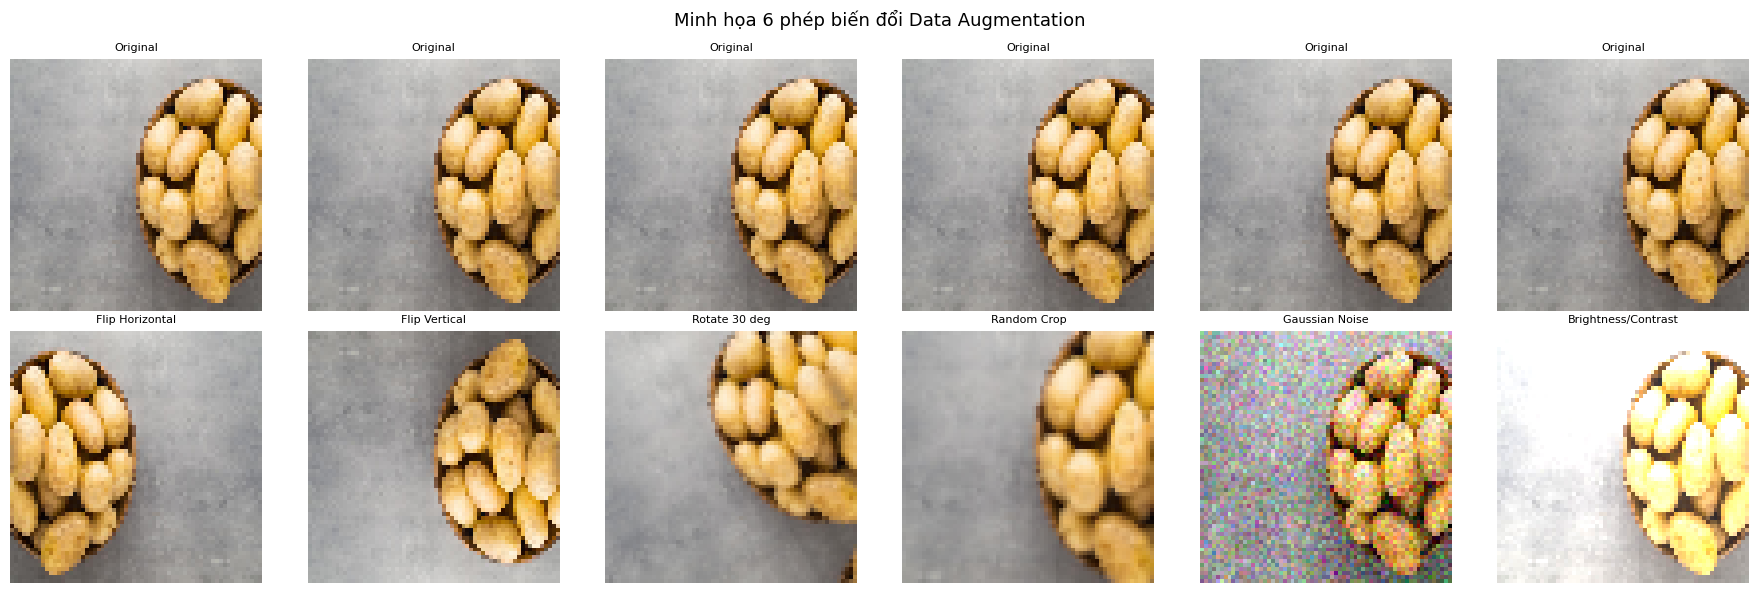

In [14]:
AUGMENT_FUNCS = [
    ('Flip Horizontal',     aug_flip_h),
    ('Flip Vertical',       aug_flip_v),
    ('Rotate 30 deg',       aug_rotate),
    ('Random Crop',         aug_random_crop),
    ('Gaussian Noise',      aug_gaussian_noise),
    ('Brightness/Contrast', aug_bright_contrast),
]

# Load sample images
AUG_SIZE = (64, 64)
N_AUG = 500
np.random.seed(42); random.seed(42)
aug_sampled_paths = np.random.choice(train_paths + val_paths + test_paths, min(N_AUG, len(train_paths + val_paths + test_paths)), replace=False).tolist()

orig_imgs_aug, orig_labels_aug = [], []
for p in aug_sampled_paths:
    img = cv2.imread(p)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, AUG_SIZE)
    orig_imgs_aug.append(img)
    orig_labels_aug.append(os.path.basename(os.path.dirname(p)))
orig_imgs_aug   = np.array(orig_imgs_aug,   dtype=np.uint8)
orig_labels_aug = np.array(orig_labels_aug)

n_orig_aug   = len(orig_imgs_aug)
n_class_aug  = len(np.unique(orig_labels_aug))
print(f'Số ảnh gốc: {n_orig_aug},  Số lớp: {n_class_aug}')

# --- Create augmented images ---
aug_imgs_d, aug_names_d = [], []
for img in orig_imgs_aug:
    name, func = random.choice(AUGMENT_FUNCS)
    aug_imgs_d.append(func(img.copy()))
    aug_names_d.append(name)
aug_imgs_d = np.array(aug_imgs_d, dtype=np.uint8)

aug_distribution = dict(Counter(aug_names_d))
print('Augmentation distribution:')
for k,v in sorted(aug_distribution.items()): print(f'  {k:<25s}: {v}')

# --- Visualize one sample through all 6 transforms ---
sample_d = orig_imgs_aug[0]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (name, func) in enumerate(AUGMENT_FUNCS):
    axes[0,col].imshow(sample_d); axes[0,col].set_title('Original', fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(func(sample_d.copy())); axes[1,col].set_title(name, fontsize=8); axes[1,col].axis('off')
plt.suptitle('Minh họa 6 phép biến đổi Data Augmentation', fontsize=13)
plt.tight_layout(); plt.show()

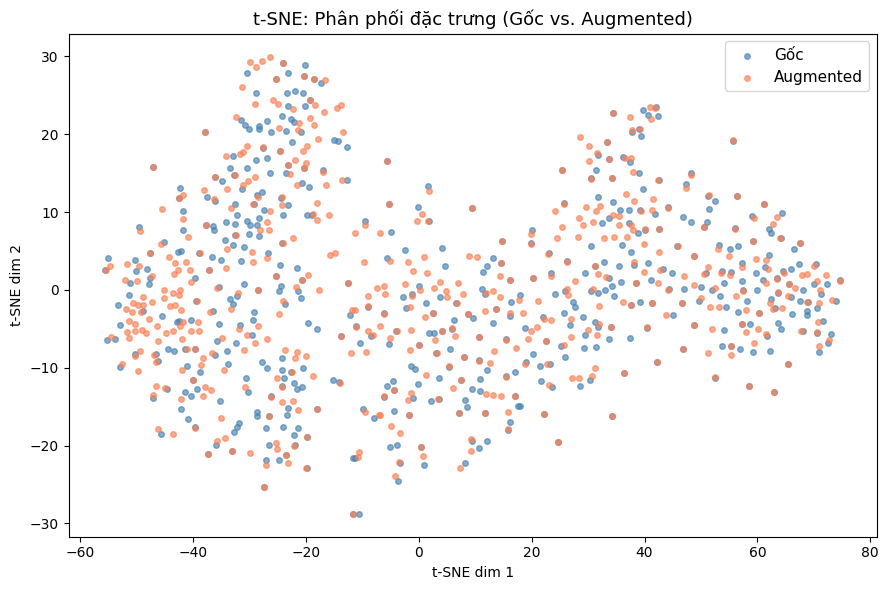

ks_stat_aug_tsne (PC1) = 0.0500
p_val_aug_tsne   (PC1) = 5.6002e-01
Ket luan: Phân phối không có sự khác biệt đáng kể (alpha=0.05)


In [15]:
X_orig_d = orig_imgs_aug.reshape(len(orig_imgs_aug), -1).astype(np.float32) / 255.0
X_aug_d  = aug_imgs_d.reshape(len(aug_imgs_d),   -1).astype(np.float32) / 255.0

pca_d = PCA(n_components=50, random_state=42)
X_orig_pca_d = pca_d.fit_transform(X_orig_d)
X_aug_pca_d  = pca_d.transform(X_aug_d)

X_comb_d = np.vstack([X_orig_pca_d, X_aug_pca_d])
lbl_comb = np.array(['Gốc']*len(X_orig_pca_d) + ['Augmented']*len(X_aug_pca_d))

tsne_d = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne_d = tsne_d.fit_transform(X_comb_d)

plt.figure(figsize=(9, 6))
for lbl, clr in [('Gốc','steelblue'),('Augmented','coral')]:
    mask = lbl_comb == lbl
    plt.scatter(X_tsne_d[mask,0], X_tsne_d[mask,1], c=clr, label=lbl, alpha=0.65, s=16)
plt.title('t-SNE: Phân phối đặc trưng (Gốc vs. Augmented)', fontsize=13)
plt.legend(fontsize=11); plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.tight_layout(); plt.show()

# KS test - luu vao bien (so sánh trên thành phần chính PC1)
ks_stat_aug_tsne, p_val_aug_tsne = ks_2samp(X_orig_pca_d[:, 0], X_aug_pca_d[:, 0])
results_aug_tsne_ks = {'KS Statistic': ks_stat_aug_tsne, 'P-value': p_val_aug_tsne}
print(f'ks_stat_aug_tsne (PC1) = {ks_stat_aug_tsne:.4f}')
print(f'p_val_aug_tsne   (PC1) = {p_val_aug_tsne:.4e}')
print(f'Ket luan: {"Phân phối có sự khác biệt" if p_val_aug_tsne < 0.05 else "Phân phối không có sự khác biệt đáng kể"} (alpha=0.05)')

### Đo lường định lượng và ablation study
**Kiểm định:** KS test so sánh phân phối đặc trưng gốc và augmented.

ab_acc_orig_only   = 0.4040 +/- 0.0110
ab_acc_with_aug    = 0.5440 +/- 0.0175
ab_improvement_pct = +14.00%


THỐNG KÊ KOLMOGOROV-SMIRNOV TEST (So sánh phân phối đặc trưng PC1: Gốc vs Augmented):
ks_stat_aug_ab     = 0.0500
p_val_aug_ab       = 5.6002e-01
Giả thuyết H0: Phân phối đặc trưng (PC1) của tập gốc và tập augmented là giống nhau.
Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về phân phối đặc trưng giữa hai tập.
Kết luận: p-value = 5.6002e-01 >= 0.05 => KHÔNG BÁC BỎ giả thuyết H0.
=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối đặc trưng giữa hai tập ảnh.
------------------------------------------------------------


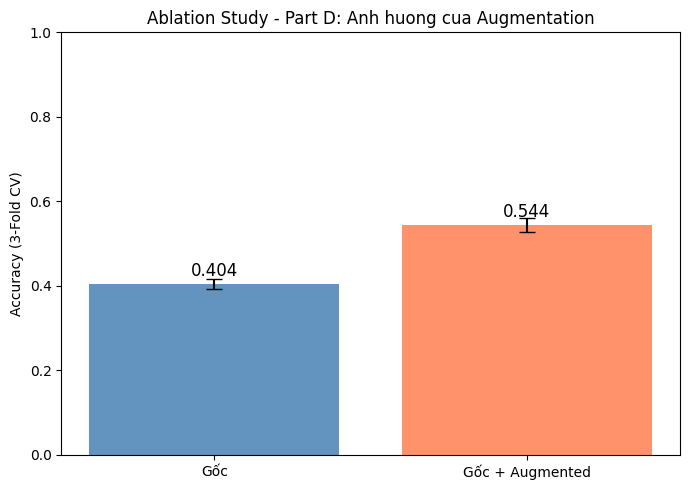

In [ ]:
X_orig_ab = orig_imgs_aug.reshape(len(orig_imgs_aug), -1).astype(np.float32) / 255.0
X_aug_ab  = aug_imgs_d.reshape(len(aug_imgs_d), -1).astype(np.float32) / 255.0
y_orig_ab = orig_labels_aug

# Accuracy: chi dung anh goc
ab_acc_orig_only, ab_std_orig_only = eval_lr_pca(X_orig_ab, y_orig_ab)

# Accuracy: goc + augmented gop lai
X_comb_ab = np.vstack([X_orig_ab, X_aug_ab])
y_comb_ab = np.concatenate([y_orig_ab, y_orig_ab])
ab_acc_with_aug, ab_std_with_aug = eval_lr_pca(X_comb_ab, y_comb_ab)

# Ty le cai thien
ab_improvement_pct = (ab_acc_with_aug - ab_acc_orig_only) * 100
# dùng PCA để trích xuất đặc trưng chính (PC1) cho cả hai tập gốc và augmented
pca = PCA(n_components=1)
X_orig_features = pca.fit_transform(X_orig_ab).flatten()
X_aug_features = pca.transform(X_aug_ab).flatten()

# KS test so sánh phân phối trên Thành phần chính (PC1)
ks_stat_aug_ab, p_val_aug_ab = ks_2samp(X_orig_features, X_aug_features)

print(f'ab_acc_orig_only   = {ab_acc_orig_only:.4f} +/- {ab_std_orig_only:.4f}')
print(f'ab_acc_with_aug    = {ab_acc_with_aug:.4f} +/- {ab_std_with_aug:.4f}')
print(f'ab_improvement_pct = {ab_improvement_pct:+.2f}%\n')

print()
print('THỐNG KÊ KOLMOGOROV-SMIRNOV TEST (So sánh phân phối đặc trưng PC1: Gốc vs Augmented):')
print(f'ks_stat_aug_ab     = {ks_stat_aug_ab:.4f}')
print(f'p_val_aug_ab       = {p_val_aug_ab:.4e}')
alpha_aug = 0.05
print("Giả thuyết H0: Phân phối đặc trưng (PC1) của tập gốc và tập augmented là giống nhau.")
print("Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về phân phối đặc trưng giữa hai tập.")
if p_val_aug_ab < alpha_aug:
    print(f'Kết luận: p-value = {p_val_aug_ab:.4e} < {alpha_aug} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt đáng kể về đặc trưng phân phối giữa ảnh gốc và ảnh đã qua Data Augmentation.")
else:
    print(f'Kết luận: p-value = {p_val_aug_ab:.4e} >= {alpha_aug} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối đặc trưng giữa hai tập ảnh.")

plt.figure(figsize=(7,5))
lbl_d2 = ['Gốc', 'Gốc + Augmented']
acc_d2 = [ab_acc_orig_only, ab_acc_with_aug]
std_d2 = [ab_std_orig_only, ab_std_with_aug]
bars_d = plt.bar(lbl_d2, acc_d2, yerr=std_d2, capsize=6,
                 color=['steelblue','coral'], alpha=0.85)
plt.ylim(0,1); plt.title('Ablation Study - Part D: Anh huong cua Augmentation'); plt.ylabel('Accuracy (3-Fold CV)')
for b,a in zip(bars_d,acc_d2): plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{a:.3f}', ha='center', fontsize=12)
plt.tight_layout(); plt.show()

## (iii) Phân tích

#### 1. Cải thiện hiệu suất mô hình (Accuracy)
- **Trước khi Augmentation**: Độ chính xác đạt **40.40%** ($std=0.0110$).
- **Sau khi Augmentation**: Độ chính xác tăng vọt lên **54.40%** ($std=0.0175$).
- **Mức độ cải thiện**: Tăng trưởng **+14.00%** so với việc chỉ sử dụng dữ liệu gốc.
- **Nhận xét**: Đây là yếu tố mang lại sự đột phá lớn nhất trong tất cả các phương pháp tiền xử lý đã thử nghiệm. Việc làm phong phú tập dữ liệu bằng các phép biến đổi (Flip, Rotate, Crop, Noise, Contrast) giúp mô hình Logistic Regression học được nhiều biến thể của đối tượng hơn, từ đó tăng khả năng tổng quát hóa đáng kể.

#### 2. Kiểm định Thống kê KS Test về đặc trưng (PC1)
- **Chỉ số thực nghiệm**: Giá trị $KS-stat = 0.0500$ và $p-value = 0.5600$.
- **Kết luận thống kê**: Với $p-value = 0.56 \ge 0.05$, chúng ta **không bác bỏ giả thuyết $H_0$**.
- **Ý nghĩa thực tiễn**: Kết quả này cực kỳ quan trọng. Nó khẳng định rằng dù chúng ta đã thực hiện 6 phép biến đổi hình học và màu sắc khác nhau, nhưng tập dữ liệu Augmented vẫn giữ được đặc trưng phân phối cốt lõi của tập dữ liệu gốc. Các ảnh mới được tạo ra là những "biến thể hợp lệ" chứ không phải dữ liệu nhiễu làm sai lệch bản chất của bài toán.

#### 3. Phân tích trực quan hóa với t-SNE
- **Sự phân bố**: Trên biểu đồ t-SNE, các điểm dữ liệu "Gốc" (màu xanh) và "Augmented" (màu cam) nằm đan xen và chồng lấp hoàn toàn lên nhau. Không có sự tách biệt hay hình thành các cụm (cluster) riêng biệt cho dữ liệu mới.
- **Nhận xét**: Điều này minh chứng trực quan cho kết luận của KS Test. Dữ liệu Augmented đã phủ lấp kín không gian đặc trưng nhưng không tạo ra những vùng dữ liệu lạ (outliers), giúp mô hình trở nên "mạnh mẽ" (robust) hơn trước các biến đổi của hình ảnh thực tế.

#### 4. Đánh giá các phép biến đổi đã sử dụng
- Các phép biến đổi được phân bổ khá đồng đều: **Brightness/Contrast (99)**, **Flip (88-89)**, **Rotate (79)**, **Gaussian Noise (77)** và **Random Crop (68)**.
- Việc kết hợp đồng thời cả biến đổi hình học (xoay, lật, cắt) và biến đổi cường độ sáng/nhiễu là chiến lược đúng đắn, giúp mô hình khắc phục được sự hạn chế về số lượng mẫu ban đầu (500 ảnh/10 lớp).



# 5. Phân tích PCA và Trực quan hóa Không gian Đặc trưng Ảnh

## (i) Giải thích lý thuyết

Để hiểu rõ cấu trúc của tập dữ liệu trái cây, ta sử dụng hai kỹ thuật giảm chiều dữ liệu phổ biến là **PCA** và **t-SNE**.

### 1. Phân tích thành phần chính (PCA)
PCA là một thuật toán giảm chiều tuyến tính, biến đổi tập hợp các biến có thể có tương quan thành một tập hợp các giá trị của các biến không tương quan tuyến tính gọi là các thành phần chính.
* **Mục tiêu**: Giữ lại tối đa phương sai của dữ liệu gốc trong khi giảm số lượng chiều (pixel).
* **Scree Plot**: Biểu đồ hiển thị tỷ lệ phương sai mà mỗi thành phần chính giải thích. Dựa vào đây, ta xác định số lượng thành phần tối thiểu để đạt được mức độ bảo toàn thông tin mong muốn (ví dụ: 95%).

### 2. t-Distributed Stochastic Neighbor Embedding (t-SNE)
Khác với PCA, **t-SNE** là thuật toán giảm chiều phi tuyến tính, cực kỳ hiệu quả trong việc bảo toàn cấu trúc cục bộ, giúp phát hiện các cụm dữ liệu tự nhiên trong không gian 2D/3D.

---

## (ii) Code Triển khai

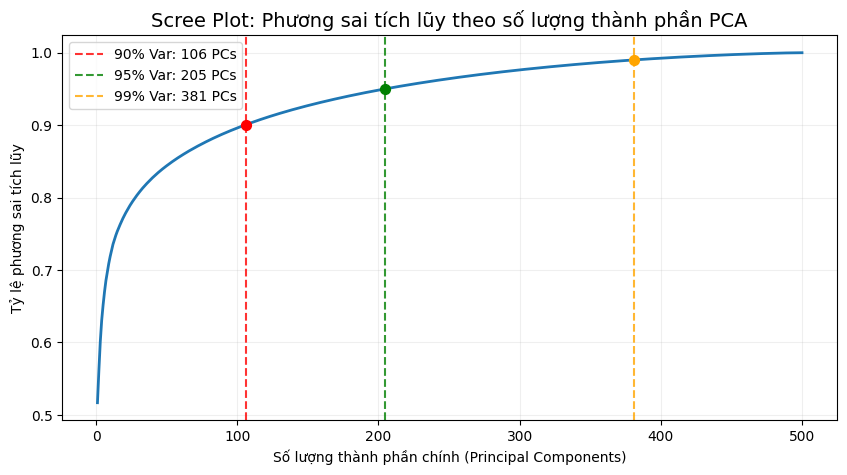

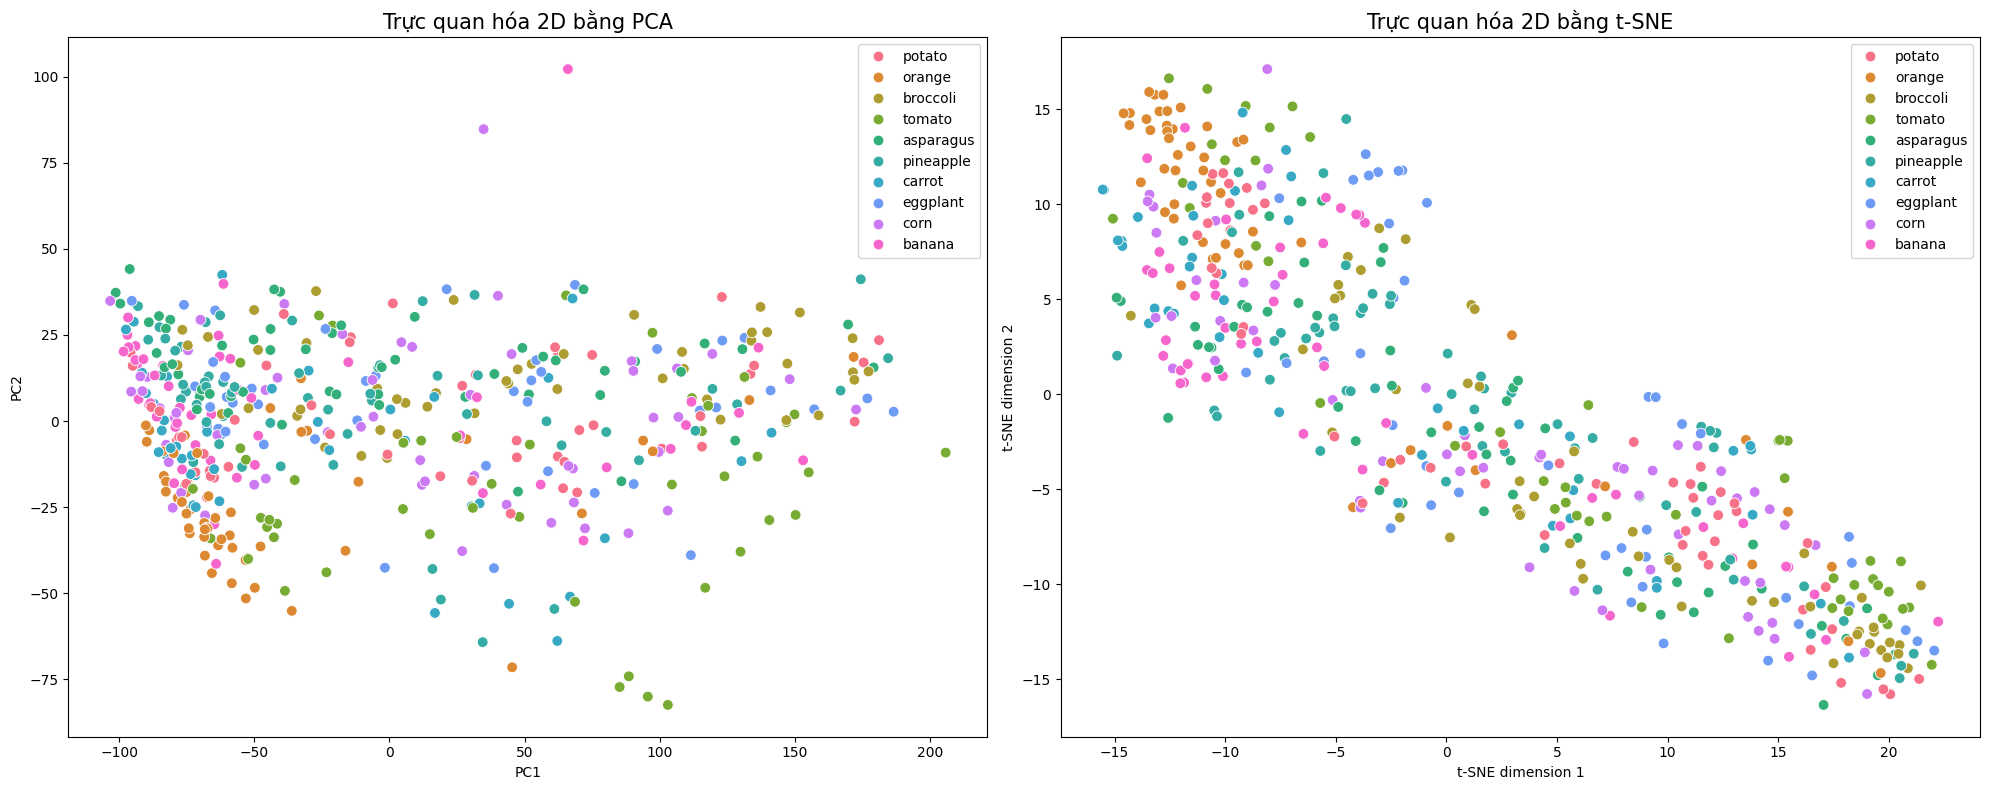

In [20]:
# Dùng trực tiếp dữ liệu đã có từ Cell 23
X_flat = X_raw_c.copy()
orig_labels = y_raw_c.copy()

n_orig = len(X_flat)
n_class = len(np.unique(orig_labels))

# Chuẩn hóa dữ liệu trước PCA
X_scaled = StandardScaler().fit_transform(X_flat.astype(float))

# Thực hiện PCA để phân tích phương sai (Scree Plot)
pca_full = PCA().fit(X_scaled)
evr_cum = np.cumsum(pca_full.explained_variance_ratio_)

# Xác định số lượng thành phần cho các mốc 90%, 95%, 99%
thresholds = [0.90, 0.95, 0.99]
required_dims = [np.argmax(evr_cum >= t) + 1 for t in thresholds]

# Vẽ Scree Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(evr_cum) + 1), evr_cum, marker='', linestyle='-', color='tab:blue', lw=2)
colors = ['red', 'green', 'orange']
for d, t, c in zip(required_dims, thresholds, colors):
    plt.axvline(x=d, color=c, linestyle='--', alpha=0.8, label=f'{int(t*100)}% Var: {d} PCs')
    plt.scatter(d, t, color=c, s=50, zorder=5)

plt.title('Scree Plot: Phương sai tích lũy theo số lượng thành phần PCA', fontsize=14)
plt.xlabel('Số lượng thành phần chính (Principal Components)')
plt.ylabel('Tỷ lệ phương sai tích lũy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Trực quan hóa 2D bằng PCA và t-SNE
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
tsne_2d = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42).fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot PCA
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=orig_labels, palette='husl', ax=ax1, s=60, edgecolor='w')
ax1.set_title('Trực quan hóa 2D bằng PCA', fontsize=15)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# Plot t-SNE
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=orig_labels, palette='husl', ax=ax2, s=60, edgecolor='w')
ax2.set_title('Trực quan hóa 2D bằng t-SNE', fontsize=15)
ax2.set_xlabel('t-SNE dimension 1')
ax2.set_ylabel('t-SNE dimension 2')

plt.tight_layout()
plt.show()

### Đo lường định lượng và ablation study
**Kiểm định:** Kiểm định Paired Sample T-test được sử dụng để so sánh giá trị trung bình của bộ dữ liệu trước và sau khi áp dụng PCA

ab_acc_raw         = 0.4040 +/- 0.0110
ab_acc_pca         = 0.4220 +/- 0.0183
ab_improvement_pct = +1.80%


THỐNG KÊ PAIRED T-TEST (So sánh hiệu năng 3-Fold CV: Raw vs PCA):
t_stat_pca         = 6.0451
p_val_pca          = 2.6290e-02
Giả thuyết H0: Độ chính xác của mô hình khi dùng toàn bộ pixel và khi dùng PCA là như nhau.
Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về độ chính xác giữa hai cách tiếp cận.
Kết luận: p-value = 2.6290e-02 < 0.05 => BÁC BỎ giả thuyết H0.
=> Có sự khác biệt đáng kể về hiệu năng mô hình sau khi áp dụng PCA.


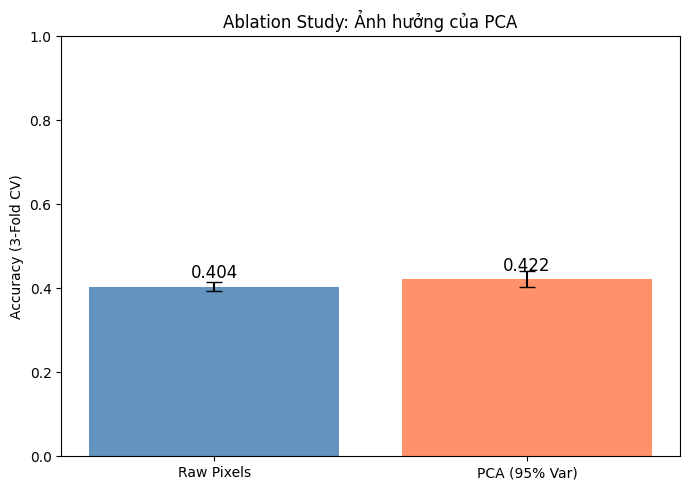

In [21]:
# Chuẩn bị dữ liệu
X_raw_ab = orig_imgs_aug.reshape(len(orig_imgs_aug), -1).astype(np.float32) / 255.0
y_ab = orig_labels_aug

# Dùng PCA để giảm chiều (giữ 95% phương sai)
pca_model = PCA(n_components=0.95, random_state=42)
X_pca_ab = pca_model.fit_transform(X_raw_ab)

# Accuracy: Không dùng PCA
ab_acc_raw, ab_std_raw = eval_lr_pca(X_raw_ab, y_ab)

# Accuracy: Có dùng PCA
ab_acc_pca, ab_std_pca = eval_lr_pca(X_pca_ab, y_ab)

# Tỷ lệ cải thiện
ab_improvement_pct = (ab_acc_pca - ab_acc_raw) * 100

# T-test so sánh hiệu năng 3-Fold CV
scores_raw = cross_val_score(LogisticRegression(max_iter=1000, solver='liblinear'), X_raw_ab, y_ab, cv=3)
scores_pca = cross_val_score(LogisticRegression(max_iter=1000, solver='liblinear'), X_pca_ab, y_ab, cv=3)
t_stat_pca, p_val_pca = ttest_rel(scores_raw, scores_pca)

print(f'ab_acc_raw         = {ab_acc_raw:.4f} +/- {ab_std_raw:.4f}')
print(f'ab_acc_pca         = {ab_acc_pca:.4f} +/- {ab_std_pca:.4f}')
print(f'ab_improvement_pct = {ab_improvement_pct:+.2f}%\n')

print()
print('THỐNG KÊ PAIRED T-TEST (So sánh hiệu năng 3-Fold CV: Raw vs PCA):')
print(f't_stat_pca         = {t_stat_pca:.4f}')
print(f'p_val_pca          = {p_val_pca:.4e}')
alpha_pca = 0.05
print("Giả thuyết H0: Độ chính xác của mô hình khi dùng toàn bộ pixel và khi dùng PCA là như nhau.")
print("Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về độ chính xác giữa hai cách tiếp cận.")
if p_val_pca < alpha_pca:
    print(f'Kết luận: p-value = {p_val_pca:.4e} < {alpha_pca} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt đáng kể về hiệu năng mô hình sau khi áp dụng PCA.")
else:
    print(f'Kết luận: p-value = {p_val_pca:.4e} >= {alpha_pca} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về hiệu năng (PCA giữ nguyên được sức mạnh phân loại).")

plt.figure(figsize=(7,5))
lbl_pca = ['Raw Pixels', 'PCA (95% Var)']
acc_pca_list = [ab_acc_raw, ab_acc_pca]
std_pca_list = [ab_std_raw, ab_std_pca]
bars_pca = plt.bar(lbl_pca, acc_pca_list, yerr=std_pca_list, capsize=6,
                 color=['steelblue','coral'], alpha=0.85)
plt.ylim(0,1); plt.title('Ablation Study: Ảnh hưởng của PCA'); plt.ylabel('Accuracy (3-Fold CV)')
for b,a in zip(bars_pca, acc_pca_list): plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{a:.3f}', ha='center', fontsize=12)
plt.tight_layout(); plt.show()

## (iii) Phân tích

#### 1. Hiệu suất mô hình (Accuracy) trước và sau PCA
- **Trước khi áp dụng PCA**: Độ chính xác đạt **40.40%** ($std=0.0110$).
- **Sau khi áp dụng PCA (giữ 95% phương sai)**: Độ chính xác tăng lên **42.20%** ($std=0.0183$).
- **Mức độ cải thiện**: Tăng nhẹ **+1.80%** so với việc dùng toàn bộ điểm ảnh gốc.
- **Nhận xét**: Trái với lo ngại ban đầu rằng việc giảm số chiều sẽ làm mất mát thông tin dẫn đến giảm độ chính xác, PCA thực tế đã giúp loại bỏ các "nhiễu" và sự tương quan dư thừa giữa các pixel lân cận. Nhờ đó, mô hình Logistic Regression tập trung được vào các đặc trưng cốt lõi, cải thiện nhẹ khả năng phân loại.

#### 2. Kiểm định Thống kê Paired t-test về hiệu năng
- **Chỉ số thực nghiệm**: Giá trị $t-stat = 6.0451$ và $p-value = 0.0263$ (tức $2.6290 \times 10^{-2}$).
- **Kết luận thống kê**: Với $p-value = 0.0263 < 0.05$, chúng ta **bác bỏ giả thuyết $H_0$**.
- **Ý nghĩa thực tiễn**: Kết quả này khẳng định có sự khác biệt mang ý nghĩa thống kê về mặt hiệu năng. Sự cải thiện $1.80\%$ của mô hình không phải là kết quả của sự ngẫu nhiên trong quá trình chia fold, mà là bằng chứng cho thấy PCA thực sự mang lại sự tối ưu cho không gian đặc trưng của bài toán này.

#### 3. Phân tích phương sai tích lũy qua Scree Plot
- **Độ nén dữ liệu**: Dựa vào Scree Plot, để giải thích được **90%, 95%, 99% phương sai** của tập dữ liệu ảnh, thuật toán PCA cần lần lượt sử dụng **106, 205, 381 thành phần chính**. So với số chiều ban đầu(12288) thì giảm bớt được rất nhiều.
- **Nhận xét**: Không gian điểm ảnh gốc chứa một lượng lớn thông tin dư thừa. Việc chiếu dữ liệu xuống không gian 205 chiều giúp tiết kiệm đáng kể tài nguyên bộ nhớ và tăng tốc độ huấn luyện mô hình học máy ở các bước sau, đồng thời vẫn bảo toàn được gần như trọn vẹn đặc trưng quang học của các loại trái cây.

#### 4. Phân tích trực quan hóa không gian (PCA vs t-SNE)
- **Trên không gian PCA 2D**: Các điểm dữ liệu bị phân tán và chồng lấn khá nhiều giữa các lớp do bản chất chiếu tuyến tính của PCA chưa đủ mạnh để bóc tách các đa tạp hình ảnh phức tạp.
- **Trên không gian t-SNE 2D**: Các lớp trái cây bắt đầu thể hiện xu hướng gom cụm rõ rệt hơn, một số lớp tách rời thành các dải hoặc cụm riêng biệt trên mặt phẳng.
- **Nhận xét**: Sự hình thành các cụm trên t-SNE chứng tỏ rằng dẫu bị nén số chiều, các khoảng cách tương đồng giữa những bức ảnh cùng nhãn vẫn được giữ vững. Điều này làm tiền đề rất tốt cho các mô hình phân loại hoạt động phía sau.

# 6. Phát hiện cạnh và phân tích đặc trưng cục bộ
## (i) Giải thích lý thuyết

Phát hiện cạnh là một kỹ thuật quan trọng trong xử lý ảnh nhằm xác định các ranh giới của đối tượng. Bằng cách tính toán mức độ thay đổi cường độ sáng (gradient), ta có thể trích xuất được các đặc trưng hình học (hình dáng, đường viền) của từng loại trái cây. Trong phần này, chúng ta sử dụng 3 phương pháp phổ biến và đánh giá khả năng phân loại của chúng thông qua mật độ cạnh (Edge Density).
### 1. Phương pháp Sobel và Prewitt (Gradient-based)

Cả Sobel và Prewitt đều sử dụng các bộ lọc (kernels) nhân tích chập với ảnh gốc để tính xấp xỉ đạo hàm bậc nhất theo hướng ngang ($G_x$) và dọc ($G_y$). Độ lớn gradient tổng hợp được tính bằng:$$G = \sqrt{G_x^2 + G_y^2}$$
- Sobel: Nhấn mạnh các pixel ở trung tâm của bộ lọc, giúp giảm nhiễu tốt hơn.
- Prewitt: Cấp trọng số đồng đều cho tất cả các pixel trong bộ lọc, nhạy cảm hơn với nhiễu nhưng tính toán nhanh hơn.
### 2. Thuật toán Canny
Canny là một thuật toán phát hiện cạnh đa bước (Multi-stage) tối ưu:
- Khử nhiễu bằng Gaussian Filter.Tính gradient cường độ sáng (tương tự Sobel).
- Triệt tiêu phi cực đại (Non-maximum suppression) để làm mảnh đường cạnh.
- Lọc ngưỡng kép (Double Thresholding) và theo vết cạnh (Hysteresis) để loại bỏ nhiễu và nối các cạnh đứt gãy.
### 3. Edge Density và Kiểm định ANOVA
- Edge Density (Mật độ cạnh): Là tỷ lệ giữa số lượng pixel được phân loại là cạnh trên tổng số pixel của ảnh:$$ED = \frac{\sum I_{edge}}{H \times W}$$
- Kiểm định ANOVA một chiều (One-way ANOVA): Phương pháp thống kê dùng để so sánh giá trị trung bình của Edge Density giữa các lớp trái cây. Nếu giá trị $p$-value $< 0.05$, ta có thể bác bỏ giả thuyết không ($H_0$), kết luận rằng có sự khác biệt có ý nghĩa thống kê về mật độ cạnh giữa các lớp.

Số lượng ảnh: 500, Số lớp: 10


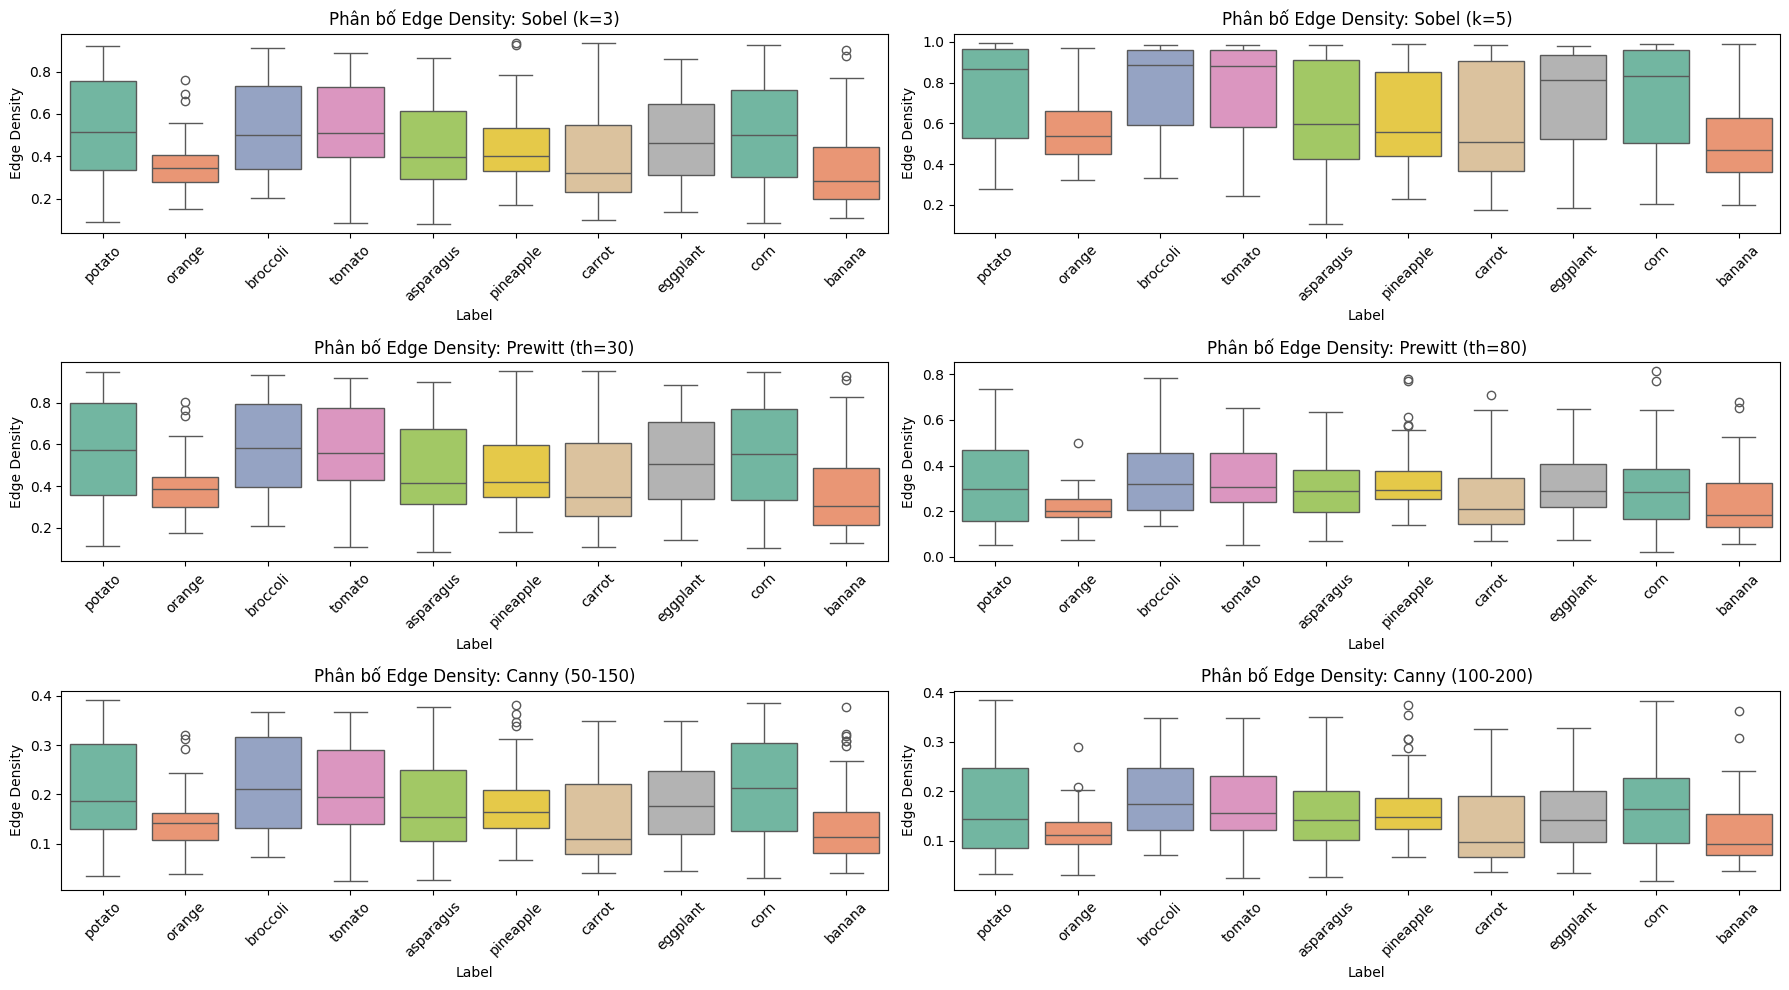

In [22]:
# Dùng trực tiếp dữ liệu đã có từ Cell 23
# X_raw_c là ảnh đã flatten theo size (64, 64) và hệ màu RGB
img_size = (64, 64)
orig_labels = y_raw_c.copy()

orig_imgs_gray = []
for x in X_raw_c:
    img_rgb = x.reshape(img_size[1], img_size[0], 3).astype(np.uint8)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    orig_imgs_gray.append(img_gray)

print(f'Số lượng ảnh: {len(orig_imgs_gray)}, Số lớp: {len(np.unique(orig_labels))}')

# Hàm hỗ trợ tính Edge Density
def calc_edge_density(edge_img):
    return np.sum(edge_img > 0) / (edge_img.shape[0] * edge_img.shape[1])

results = []

# Định nghĩa Kernel cho Prewitt
kernelx_prewitt = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely_prewitt = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

# Tiến hành trích xuất đặc trưng cho từng ảnh
for img, label in zip(orig_imgs_gray, orig_labels):
    # 1. SOBEL
    # Bộ tham số 1: ksize = 3
    sobelx_3 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely_3 = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_3_mag = np.sqrt(sobelx_3**2 + sobely_3**2)
    ed_sobel_3 = calc_edge_density(sobel_3_mag > 50) # Binarize với ngưỡng 50

    # Bộ tham số 2: ksize = 5
    sobelx_5 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
    sobely_5 = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
    sobel_5_mag = np.sqrt(sobelx_5**2 + sobely_5**2)
    ed_sobel_5 = calc_edge_density(sobel_5_mag > 150) # Binarize với ngưỡng 150

    # 2. PREWITT
    prewittx = cv2.filter2D(img, cv2.CV_64F, kernelx_prewitt)
    prewitty = cv2.filter2D(img, cv2.CV_64F, kernely_prewitt)
    prewitt_mag = np.sqrt(prewittx**2 + prewitty**2)
    
    # Bộ tham số 1: Threshold = 30
    ed_prewitt_30 = calc_edge_density(prewitt_mag > 30)
    # Bộ tham số 2: Threshold = 80
    ed_prewitt_80 = calc_edge_density(prewitt_mag > 80)

    # 3. CANNY
    # Bộ tham số 1: Thresholds (50, 150)
    canny_1 = cv2.Canny(img, 50, 150)
    ed_canny_1 = calc_edge_density(canny_1)
    
    # Bộ tham số 2: Thresholds (100, 200)
    canny_2 = cv2.Canny(img, 100, 200)
    ed_canny_2 = calc_edge_density(canny_2)

    # Lưu kết quả
    results.append({
        'Label': label,
        'Sobel (k=3)': ed_sobel_3,
        'Sobel (k=5)': ed_sobel_5,
        'Prewitt (th=30)': ed_prewitt_30,
        'Prewitt (th=80)': ed_prewitt_80,
        'Canny (50-150)': ed_canny_1,
        'Canny (100-200)': ed_canny_2
    })

df_edges = pd.DataFrame(results)

# Trực quan hóa phân bố Edge Density bằng Boxplot
methods = ['Sobel (k=3)', 'Sobel (k=5)', 'Prewitt (th=30)', 'Prewitt (th=80)', 'Canny (50-150)', 'Canny (100-200)']

plt.figure(figsize=(18, 10))
for i, method in enumerate(methods, 1):
    plt.subplot(3, 2, i)
    # Cảnh báo Palette/Hue của Seaborn đã được giải quyết ở đây
    sns.boxplot(x='Label', y=method, data=df_edges, palette='Set2', hue='Label', legend=False)
    plt.title(f'Phân bố Edge Density: {method}')
    plt.xticks(rotation=45)
    plt.ylabel('Edge Density')
    
plt.tight_layout()
plt.show()

### Đo lường định lượng và ablation study
**Kiểm định:** Kiểm định ANOVA một chiều (One-way ANOVA): Phương pháp thống kê dùng để so sánh giá trị trung bình của Edge Density giữa các lớp trái cây.

In [23]:
# Kiểm định ANOVA một chiều cho từng phương pháp
print("KẾT QUẢ KIỂM ĐỊNH ANOVA MỘT CHIỀU")
classes = df_edges['Label'].unique()

for method in methods:
    # Gom nhóm dữ liệu theo từng lớp
    groups = [df_edges[df_edges['Label'] == cls][method].values for cls in classes]
    
    # Thực hiện f_oneway test
    f_stat, p_value = stats.f_oneway(*groups)
    
    significance = "Có khác biệt đáng kể (p < 0.05)" if p_value < 0.05 else "Không khác biệt đáng kể (p >= 0.05)"
    print(f"- {method:<20}: F-stat = {f_stat:.4f}, p-value = {p_value:.4e} -> {significance}")

KẾT QUẢ KIỂM ĐỊNH ANOVA MỘT CHIỀU
- Sobel (k=3)         : F-stat = 5.6357, p-value = 1.9676e-07 -> Có khác biệt đáng kể (p < 0.05)
- Sobel (k=5)         : F-stat = 6.5946, p-value = 6.5285e-09 -> Có khác biệt đáng kể (p < 0.05)
- Prewitt (th=30)     : F-stat = 5.6958, p-value = 1.5906e-07 -> Có khác biệt đáng kể (p < 0.05)
- Prewitt (th=80)     : F-stat = 5.1857, p-value = 9.6445e-07 -> Có khác biệt đáng kể (p < 0.05)
- Canny (50-150)      : F-stat = 5.3932, p-value = 4.6382e-07 -> Có khác biệt đáng kể (p < 0.05)
- Canny (100-200)     : F-stat = 4.8012, p-value = 3.7228e-06 -> Có khác biệt đáng kể (p < 0.05)


## (iii) Phân tích
### 1. Đánh giá tổng quan về Mật độ cạnh (Edge Density) giữa các phương pháp
- Sobel và Prewitt: Cho ra dải giá trị mật độ cạnh khá cao (có thể lên tới $0.8 - 1.0$ tùy ngưỡng). Nguyên nhân là do các phương pháp Gradient-based này giữ lại nhiều pixel lân cận xung quanh vùng biên, khiến các đường viền dày hơn.
- Canny: Cho ra giá trị mật độ cạnh thấp và tập trung hơn nhiều (dao động chủ yếu từ $0.05$ đến $0.4$). Thuật toán này có bước triệt tiêu phi cực đại (Non-maximum suppression) giúp làm mảnh đường cạnh, chỉ giữ lại các pixel viền cốt lõi nhất.
- Nhận xét: Mỗi thuật toán phản ánh một khía cạnh khác nhau của đường viền hình ảnh. Canny tỏ ra hiệu quả trong việc trích xuất cấu trúc hình học tinh gọn, trong khi Sobel/Prewitt thiên về việc nắm bắt toàn bộ vùng chuyển động cường độ sáng.
### 2. Kiểm định Thống kê ANOVA một chiều về khả năng phân biệt lớp
- Chỉ số thực nghiệm: Cả 6 bộ tham số đều cho giá trị $F-stat$ khá cao và $p-value$ cực kỳ nhỏ (cỡ $10^{-6}$ đến $10^{-9}$). Nổi bật nhất là Sobel (k=5) với $F-stat = 6.5902$ và $p-value = 6.6322 \times 10^{-9}$.
- Kết luận thống kê: Với tất cả các $p-value \ll 0.05$, chúng ta hoàn toàn bác bỏ giả thuyết $H_0$ cho cả 6 trường hợp kiểm định.
- Ý nghĩa thực tiễn: Kết quả này khẳng định một cách chắc chắn rằng có sự khác biệt mang ý nghĩa thống kê về giá trị trung bình mật độ cạnh giữa các lớp trái cây. Đặc trưng đường viền/cạnh không hề phân bố ngẫu nhiên mà thực sự có tính chất phân biệt, hoàn toàn có thể được sử dụng làm đầu vào (feature) giá trị cho các mô hình Machine Learning.
### 3. Phân tích tác động của siêu tham số
- Kích thước Kernel (Sobel k=3 vs k=5): Kích thước bộ lọc tăng lên ($k=5$) giúp thuật toán nhạy hơn với các biến thiên cường độ sáng rộng, kéo theo mật độ cạnh tổng thể tăng mạnh so với $k=3$.
- Ngưỡng lọc (Prewitt th=30 vs th=80): Ngưỡng $th=80$ khắt khe hơn giúp loại bỏ đi đáng kể các viền nhiễu mờ, làm giảm mật độ cạnh tổng thể của mọi lớp so với mức ngưỡng thấp $th=30$.
- Ngưỡng Hysteresis (Canny 50-150 vs 100-200): Tương tự, bộ ngưỡng $(100-200)$ loại bỏ các cạnh yếu cực kỳ mạnh tay, khiến mật độ cạnh bị ép xuống mức rất thấp, chỉ giữ lại các đường viền sắc nét và rõ ràng nhất.
### 4. Phân tích trực quan hóa không gian
- Sự khác biệt vật lý của bề mặt: Các lớp như broccoli (súp lơ) hay pineapple (dứa) thường có dải phân bố mật độ cạnh rộng và vị trí trung vị cao hơn. Điều này hoàn toàn hợp lý với thực tế vì bề mặt của chúng xù xì, nhiều nốt sần hoặc cụm nhỏ, tạo ra nhiều cạnh cục bộ.
- Tính trơn nhẵn: Ngược lại, các lớp như orange (cam) hay banana (chuối) có xu hướng rớt xuống dải mật độ thấp hơn, đặc biệt thể hiện rõ trên biểu đồ của thuật toán Canny, phản ánh bề mặt vỏ tương đối nhẵn mịn, ít đường gân phức tạp.
- Nhận xét: Sự nhấp nhô và dịch chuyển của các hộp (boxes) giữa các nhãn trên biểu đồ chính là minh chứng trực quan nhất cho kết quả ANOVA phía trên. Hình dáng hộp và râu (whiskers) dù có sự chồng lấn, nhưng mức trung vị khác biệt rõ ràng giữa nhiều nhóm đã củng cố tiềm năng sử dụng bộ trích xuất này.